# Proyecto Final — Métodos Cuantitativos en Finanzas
## De la Optimización de Markowitz a los Modelos Multifactoriales (CAPM y APT)

**Universidad Nacional Autónoma de México | Facultad de Ciencias | Semestre 2026‑2**  
**Profesor:** Daniel Rafael Granados Olvera  
**Ayudantes:** César Fernando Gómez Mejía — Emilio Lombera Alanís  

---

### Universo de Activos Seleccionados
| # | Ticker | Instrumento | Sector | Mercado |
|---|---|---|---|---|
| 1 | MSFT | Microsoft Corp. | Tecnología | NASDAQ |
| 2 | JNJ | Johnson & Johnson | Salud | NYSE |
| 3 | XOM | Exxon Mobil Corp. | Energía | NYSE |
| 4 | V | Visa Inc. | Servicios Financieros | NYSE |
| 5 | WMT | Walmart Inc. | Consumo Básico | NYSE |
| 6 | GLD | SPDR Gold Shares ETF | Materias Primas | NYSE Arca |
| 7 | LMT | Lockheed Martin Corp. | Defensa/Aeroespacial | NYSE |
| 8 | UNP | Union Pacific Corp. | Transporte/Ferroviario | NYSE |

**Benchmark:** S&P 500 (`^GSPC`) | **Ventana temporal:** 2016-01-01 — 2026-01-01 (10 años diarios ajustados)

---

### Uso de Inteligencia Artificial
Se utilizó **Claude (Anthropic)** como herramienta de apoyo en las siguientes partes del proyecto:

| Fase | Uso de IA | Prompt principal utilizado |
|---|---|---|
| Fase 1 | Depuración de la optimización con `scipy` | *"¿Cómo defino restricciones de igualdad en `scipy.optimize.minimize` para el problema de Markowitz con restricción long-only?"* |
| Fase 1 | Construcción del loop de Monte Carlo | *"¿Cómo genero N portafolios con distribución uniforme exacta sobre el símplex usando numpy.random.dirichlet?"* |
| Fase 2 | Regresión OLS con `statsmodels` | *"¿Cómo agrego una constante y extraigo el intervalo de confianza al 95% de la beta en una regresión OLS con statsmodels?"* |
| Fase 3 | Selección y descarga de factores macroeconómicos | *"¿Cuál es la alternativa a pandas_datareader para descargar datos de FRED en Python 3.11+ sin usar distutils?"* |
| Fase 3 | Corrección del rezago del CPI | *"La inflación CPIAUCSL se publica con un mes de rezago y me genera NaN en el último mes. ¿Cómo aplicar ffill antes del dropna para no perder observaciones?"* |
| Fase 4 | Análisis de sensibilidad | *"¿Cómo estructuro un loop que re-optimice la cartera de Markowitz para distintas ventanas temporales y grafique la composición resultante?"* |


## Fase 0 — Configuración del entorno

In [1]:
# Instalación de librerías especializadas
# 
# Ejecutar esta celda UNA SOLA VEZ. Luego reiniciar el kernel si es necesario.
#
# NOTA DE COMPATIBILIDAD (Python 3.14.5):
#   - pandas_datareader NO es compatible con Python 3.12+ porque depende de
#     'distutils', módulo que fue eliminado definitivamente en Python 3.12+.
#   - Por esta razón, los datos macroeconómicos de FRED se descargan directamente
#     con 'requests' (librería estándar incluida en Python) sin necesidad de
#     pandas_datareader.
#   - scipy, statsmodels y yfinance sí son compatibles con Python 3.14.5.
%pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels requests --quiet


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1 -> 26.1.1
[notice] To update, run: C:\Users\fupr2\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# Importación del ecosistema cuantitativo
#
# NOTA: pandas_datareader fue ELIMINADO de este proyecto por incompatibilidad
# con Python 3.11+ (requiere 'distutils' que fue removido del lenguaje).
# Los datos de FRED se obtienen directamente con 'requests' en la Fase 3.
import yfinance as yf                      # Descarga precios históricos (Yahoo Finance)
import pandas as pd                         # Manipulación de DataFrames y series de tiempo
import numpy as np                          # Álgebra lineal y operaciones matriciales
import matplotlib.pyplot as plt             # Graficación base
import matplotlib.ticker as mticker         # Formato de ejes
import seaborn as sns                       # Visualización estadística avanzada
from scipy.optimize import minimize         # Optimización numérica (Markowitz y Sharpe)
from scipy import stats as sp_stats         # Tests estadísticos (Jarque-Bera, etc.)
import statsmodels.api as sm                # Regresiones OLS para CAPM y APT
import requests                             # Descarga directa de datos desde FRED API
import warnings
warnings.filterwarnings('ignore')

# Configuración visual global — estilo académico limpio
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.8,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
})
sns.set_palette("tab10")



In [2]:
# Parámetros globales del proyecto
# 
# Centralizar estos parámetros aquí facilita muchísimo el análisis de sensibilidad
# en la Fase 4: basta cambiar un valor aquí y re-ejecutar todo el notebook.

# Universo de inversión: 8 activos diversificados + benchmark
# Todos los activos cotizan en USD (NYSE/NASDAQ), eliminando riesgo cambiario.
ACTIVOS    = ['GLD', 'JNJ', 'LMT', 'MSFT', 'UNP', 'V', 'WMT', 'XOM']
BENCHMARK  = '^GSPC'
TODOS      = ACTIVOS + [BENCHMARK]
N          = len(ACTIVOS)           # Número de activos riesgosos en el portafolio

# Ventana temporal: 10 años exactos de datos diarios ajustados
FECHA_INICIO = "2016-01-01"
FECHA_FIN    = "2026-01-01"

# Convención de mercado estándar para anualización
TRADING_DAYS = 252                  # Días hábiles bursátiles por año

# Tasa libre de riesgo (Rf) — Justificación:
# Usamos el rendimiento del US Treasury Note a 10 años (~4.33% en mayo 2026).
# Esta elección es estándar para portafolios denominados en dólares, ya que el
# T-Note a 10 años es líquido, libre de riesgo de crédito y refleja expectativas
# de tasas de largo plazo coherentes con el horizonte de 10 años del análisis.
RF_ANUAL  = 0.0433
RF_DIARIA = np.log(1 + RF_ANUAL) / TRADING_DAYS  # Conversión logarítmica (para APT mensual y series log)
RF_DIARIA_SIMPLE = RF_ANUAL / TRADING_DAYS        # Conversión simple (para excesos de retorno en CAPM diario)
RF_MENSUAL= np.log(1 + RF_ANUAL) / 12           # Conversión exacta para retornos logarítmicos

print(f"Activos del portafolio  : {ACTIVOS}")
print(f"Benchmark               : {BENCHMARK}")
print(f"Periodo de análisis     : {FECHA_INICIO} — {FECHA_FIN}")
print(f"Tasa libre de riesgo Rf : {RF_ANUAL:.2%} anual  |  {RF_DIARIA:.6f} diaria")


Activos del portafolio  : ['GLD', 'JNJ', 'LMT', 'MSFT', 'UNP', 'V', 'WMT', 'XOM']
Benchmark               : ^GSPC
Periodo de análisis     : 2016-01-01 — 2026-01-01
Tasa libre de riesgo Rf : 4.33% anual  |  0.000168 diaria


---
## Fase 1 — Datos y Frontera Eficiente de Markowitz

In [3]:
# Adquisición y limpieza de datos históricos de precios
# 
# Descargamos los precios de cierre ajustados para los 9 instrumentos.
# El parámetro auto_adjust=True aplica automáticamente correcciones por:
#   - Splits de acciones 
#   - Dividendos en efectivo (ajusta el precio hacia atrás para reflejar retornos totales)
# Esto garantiza que los retornos calculados sean retornos totales económicamente
# significativos, no solo ganancias de capital.

print("Descargando 10 años de datos diarios desde Yahoo Finance...")
df_raw = yf.download(
    TODOS,
    start=FECHA_INICIO,
    end=FECHA_FIN,
    auto_adjust=True,
    progress=True
)['Close']

# Aplanamos el MultiIndex si existe (yfinance lo genera cuando hay varios tickers)
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

# ─── Diagnóstico inicial ───
print(f"\nDimensiones del DataFrame crudo: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print("\nValores nulos por activo ANTES de la limpieza:")
print(df_raw.isna().sum().to_string())

# ─── Limpieza: eliminación de filas incompletas (dropna) ───
# Todos los activos cotizan en USD (NYSE/NASDAQ), por lo que comparten el mismo
# calendario bursátil estadounidense. Pueden aparecer NaN si algún activo no
# reporta precio en una fecha específica (primera fecha de cotización, etc.).
#
# Comparativa de métodos:
#   • ffill: propaga el precio del día anterior. Introduce retornos artificialmente cero.
#   • dropna: elimina la fila completa si falta cualquier activo.
#
# Elegimos dropna porque en el cálculo de la matriz de covarianza, propagar
# precios "congelados" subestimaría la correlación real entre activos. La pérdida
# de observaciones es mínima dado que todos los activos son USD/NYSE/NASDAQ.
df = df_raw.dropna()

print(f"\nDimensiones DESPUÉS de la limpieza: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Observaciones eliminadas: {len(df_raw) - len(df)} días")
print(f"\nPrimeras 3 filas del dataset limpio:")
print(df.head(3).round(2))

Descargando 10 años de datos diarios desde Yahoo Finance...


[*********************100%***********************]  9 of 9 completed


Dimensiones del DataFrame crudo: 2514 filas × 9 columnas

Valores nulos por activo ANTES de la limpieza:
Ticker
GLD      0
JNJ      0
LMT      0
MSFT     0
UNP      0
V        0
WMT      0
XOM      0
^GSPC    0

Dimensiones DESPUÉS de la limpieza: 2514 filas × 9 columnas
Observaciones eliminadas: 0 días

Primeras 3 filas del dataset limpio:
Ticker         GLD    JNJ     LMT   MSFT    UNP      V    WMT    XOM    ^GSPC
Date                                                                         
2016-01-04  102.89  75.34  162.38  47.77  62.47  70.29  17.01  49.32  2012.66
2016-01-05  103.18  75.65  166.22  47.99  61.87  70.82  17.41  49.74  2016.71
2016-01-06  104.67  75.27  165.74  47.12  59.20  69.89  17.59  49.33  1990.26


In [4]:
# Transformación de precios a retornos
#
# Calculamos dos tipos de retornos:
#
#   1. Retornos simples:
#      Rt = (Pt - Pt-1) / Pt-1
#
#      Se usan en la optimización de Markowitz, porque el rendimiento
#      del portafolio es lineal en los pesos:
#
#      E[Rp] = Σ wi E[Ri]
#
#   2. Retornos logarítmicos:
#      rt = ln(Pt / Pt-1) = ln(Pt) - ln(Pt-1)
#
#      Se conservan para análisis estadístico de series temporales,
#      pruebas de normalidad y agregación mensual en la fase APT.
#
# Los log-retornos tienen ventajas útiles:
#   - Son aditivos en el tiempo: la suma de log-retornos equivale al
#     log-retorno acumulado.
#   - Suelen ser más simétricos que los retornos simples.
#   - Son más estacionarios que los precios.

# Retornos simples
returns_simple = df.pct_change().dropna()

# Retornos logarítmicos
returns_log = np.log(df / df.shift(1)).dropna()

# Para Markowitz usamos retornos simples de los activos seleccionados.
# Esto mantiene la interpretación:
#
#   Rp = Σ wi Ri
#
# El benchmark se separa para las fases posteriores de CAPM y APT.
ret_activos = returns_simple[ACTIVOS].copy()
ret_mercado = returns_simple[BENCHMARK].copy()

print(f"Observaciones de retornos diarios disponibles: {len(ret_activos)}")
print(f"Rango de fechas: {ret_activos.index[0].date()} — {ret_activos.index[-1].date()}")
print("\nPrimeras 3 filas de retornos simples de los activos:")
print(ret_activos.head(3).round(6))

Observaciones de retornos diarios disponibles: 2513
Rango de fechas: 2016-01-05 — 2025-12-31

Primeras 3 filas de retornos simples de los activos:
Ticker           GLD       JNJ       LMT      MSFT       UNP         V  \
Date                                                                     
2016-01-05  0.002819  0.004179  0.023685  0.004562 -0.009624  0.007530   
2016-01-06  0.014441 -0.005055 -0.002887 -0.018165 -0.043217 -0.013111   
2016-01-07  0.014140 -0.011654 -0.019942 -0.034783 -0.023386 -0.019663   

Ticker           WMT       XOM  
Date                            
2016-01-05  0.023755  0.008521  
2016-01-06  0.010013 -0.008321  
2016-01-07  0.023289 -0.016006  


  ESTADÍSTICAS ANUALIZADAS DE LOS ACTIVOS
        μ anual (%)  σ anual (%)  Ratio μ/σ
Ticker                                     
GLD           14.62        14.80      0.988
JNJ           11.71        18.36      0.638
LMT           13.59        23.13      0.587
MSFT          26.76        26.76      1.000
UNP           16.25        25.37      0.640
V             19.07        24.46      0.780
WMT           21.14        21.58      0.980
XOM           12.69        27.86      0.456

Benchmark S&P 500: μ=13.93%  σ=18.13%

PROPIEDADES DE LA MATRIZ DE COVARIANZA Σ:
  Simétrica (Σ = Σᵀ)               : True
  Semidefinida positiva (λ ≥ 0)    : True
  Rango de eigenvalores             : [0.0204, 0.1904]


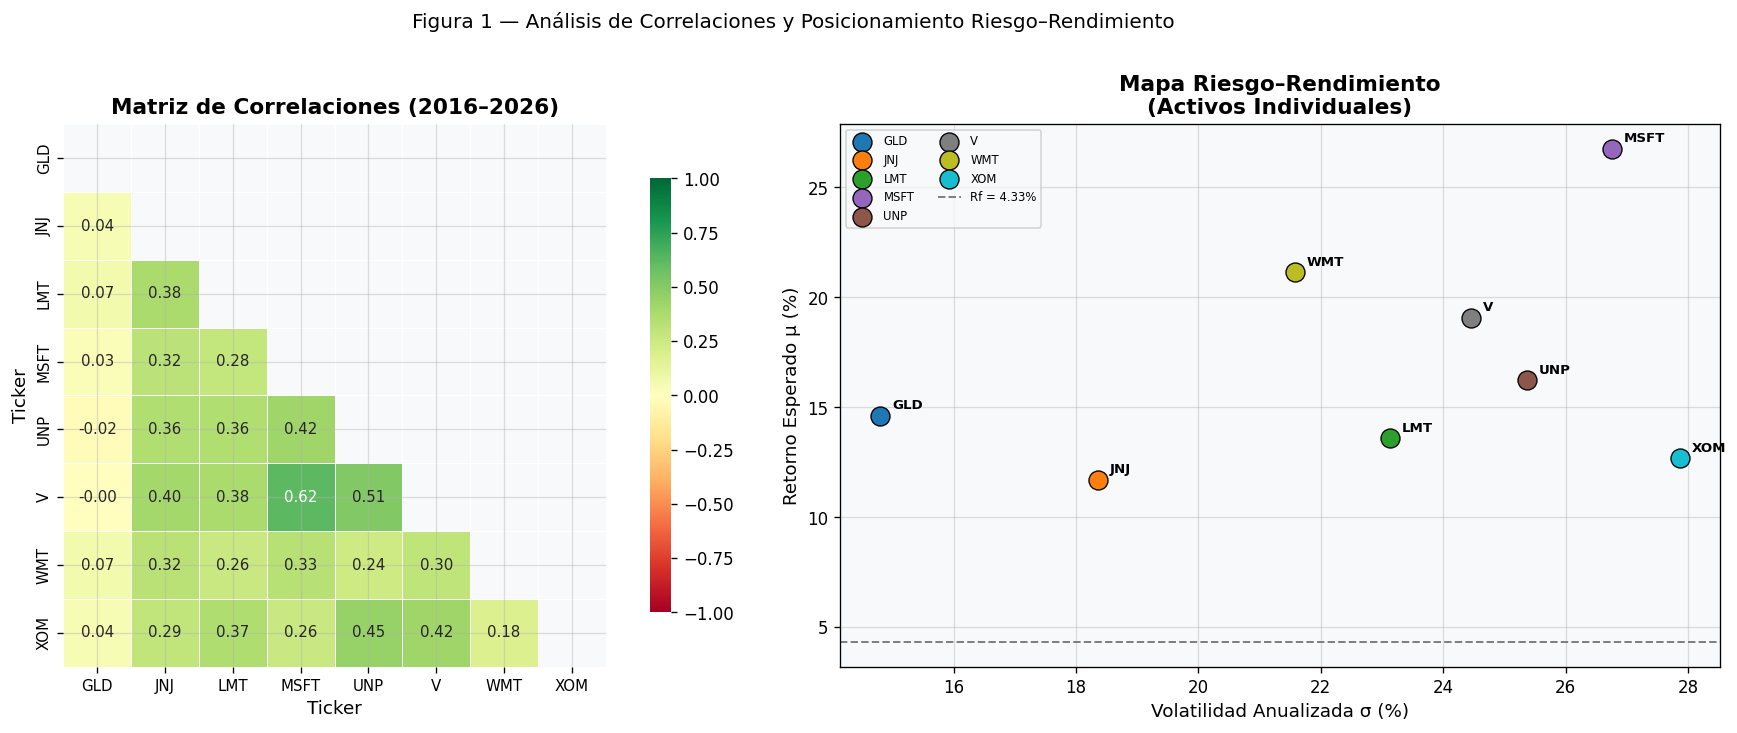


Figura 1 guardada.


In [5]:
# Métricas estadísticas anualizadas y mapa de calor de correlaciones
# 
# Bajo el supuesto de retornos i.i.d. (independientes e idénticamente distribuidos),
# las métricas estadísticas se escalan de frecuencia diaria a anual así:
#
#   μ_anual   = μ_diaria  × 252
#   σ²_anual  = σ²_diaria × 252  →  σ_anual = σ_diaria × √252
#   Σ_anual   = Σ_diaria  × 252

# ─── Métricas anualizadas ───
mu_anual     = ret_activos.mean()  * TRADING_DAYS    # Vector de retornos esperados simples anualizados (N,)
sigma2_anual = ret_activos.var()   * TRADING_DAYS    # Vector de varianzas (N,)
sigma_anual  = np.sqrt(sigma2_anual)                 # Vector de desviaciones estándar (N,)
cov_anual    = ret_activos.cov()   * TRADING_DAYS    # Matriz de covarianza N×N

# También necesitamos métricas del mercado
mu_mercado   = ret_mercado.mean() * TRADING_DAYS
sigma_mercado= ret_mercado.std()  * np.sqrt(TRADING_DAYS)
var_mercado  = ret_mercado.var()  * TRADING_DAYS

print("=" * 58)
print("  ESTADÍSTICAS ANUALIZADAS DE LOS ACTIVOS")
print("=" * 58)
stats_tabla = pd.DataFrame({
    'μ anual (%)' : (mu_anual * 100).round(2),
    'σ anual (%)' : (sigma_anual * 100).round(2),
    'Ratio μ/σ'   : (mu_anual / sigma_anual).round(3),
})
print(stats_tabla.to_string())
print(f"\nBenchmark S&P 500: μ={mu_mercado:.2%}  σ={sigma_mercado:.2%}")

print("\nPROPIEDADES DE LA MATRIZ DE COVARIANZA Σ:")
print(f"  Simétrica (Σ = Σᵀ)               : {np.allclose(cov_anual, cov_anual.T)}")
eigvals = np.linalg.eigvals(cov_anual.values)
print(f"  Semidefinida positiva (λ ≥ 0)    : {np.all(eigvals >= -1e-9)}")
print(f"  Rango de eigenvalores             : [{eigvals.min():.4f}, {eigvals.max():.4f}]")

# ─── Figura 1: Mapa de calor de correlaciones ───
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = ret_activos.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=0.6,
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1, annot_kws={"size": 9})
axes[0].set_title('Matriz de Correlaciones (2016–2026)', fontweight='bold')
axes[0].tick_params(labelsize=9)

# Gráfico riesgo-rendimiento de activos individuales
colors_ind = plt.cm.tab10(np.linspace(0, 1, N))
for i, activo in enumerate(ACTIVOS):
    axes[1].scatter(sigma_anual[activo]*100, mu_anual[activo]*100,
                    s=130, color=colors_ind[i], zorder=5,
                    edgecolors='black', linewidth=0.8, label=activo)
    axes[1].annotate(activo,
                     (sigma_anual[activo]*100, mu_anual[activo]*100),
                     textcoords="offset points", xytext=(7, 4), fontsize=8, fontweight='bold')
axes[1].axhline(RF_ANUAL*100, color='gray', linestyle='--', linewidth=1.2,
                label=f'Rf = {RF_ANUAL:.2%}')
axes[1].set_xlabel('Volatilidad Anualizada σ (%)', fontsize=11)
axes[1].set_ylabel('Retorno Esperado μ (%)', fontsize=11)
axes[1].set_title('Mapa Riesgo–Rendimiento\n(Activos Individuales)', fontweight='bold')
axes[1].legend(fontsize=7, ncol=2)

plt.suptitle('Figura 1 — Análisis de Correlaciones y Posicionamiento Riesgo–Rendimiento',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig1_estadisticas.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nFigura 1 guardada.")

TEST DE NORMALIDAD DE LOS RETORNOS (Jarque-Bera)
Activo          Asimetría  Curtosis exc.   p-valor JB       Decisión
--------------------------------------------------------------------
GLD               -0.2819         3.5876    4.91e-299   No normal ***
JNJ               -0.4321        10.1414     0.00e+00   No normal ***
LMT               -0.8928        15.3643     0.00e+00   No normal ***
MSFT              -0.1652         7.9397     0.00e+00   No normal ***
UNP               -0.2491         9.9317     0.00e+00   No normal ***
V                 -0.1129        10.1700     0.00e+00   No normal ***
WMT                0.0777        14.4171     0.00e+00   No normal ***
XOM               -0.2112         6.5629     0.00e+00   No normal ***

Interpretación:
  • Curtosis en exceso > 0 indica colas más pesadas que la normal,
    es decir, una mayor frecuencia de retornos extremos.
  • Asimetría negativa sugiere una cola izquierda relativamente más larga,
    asociada a caídas extremas más pr

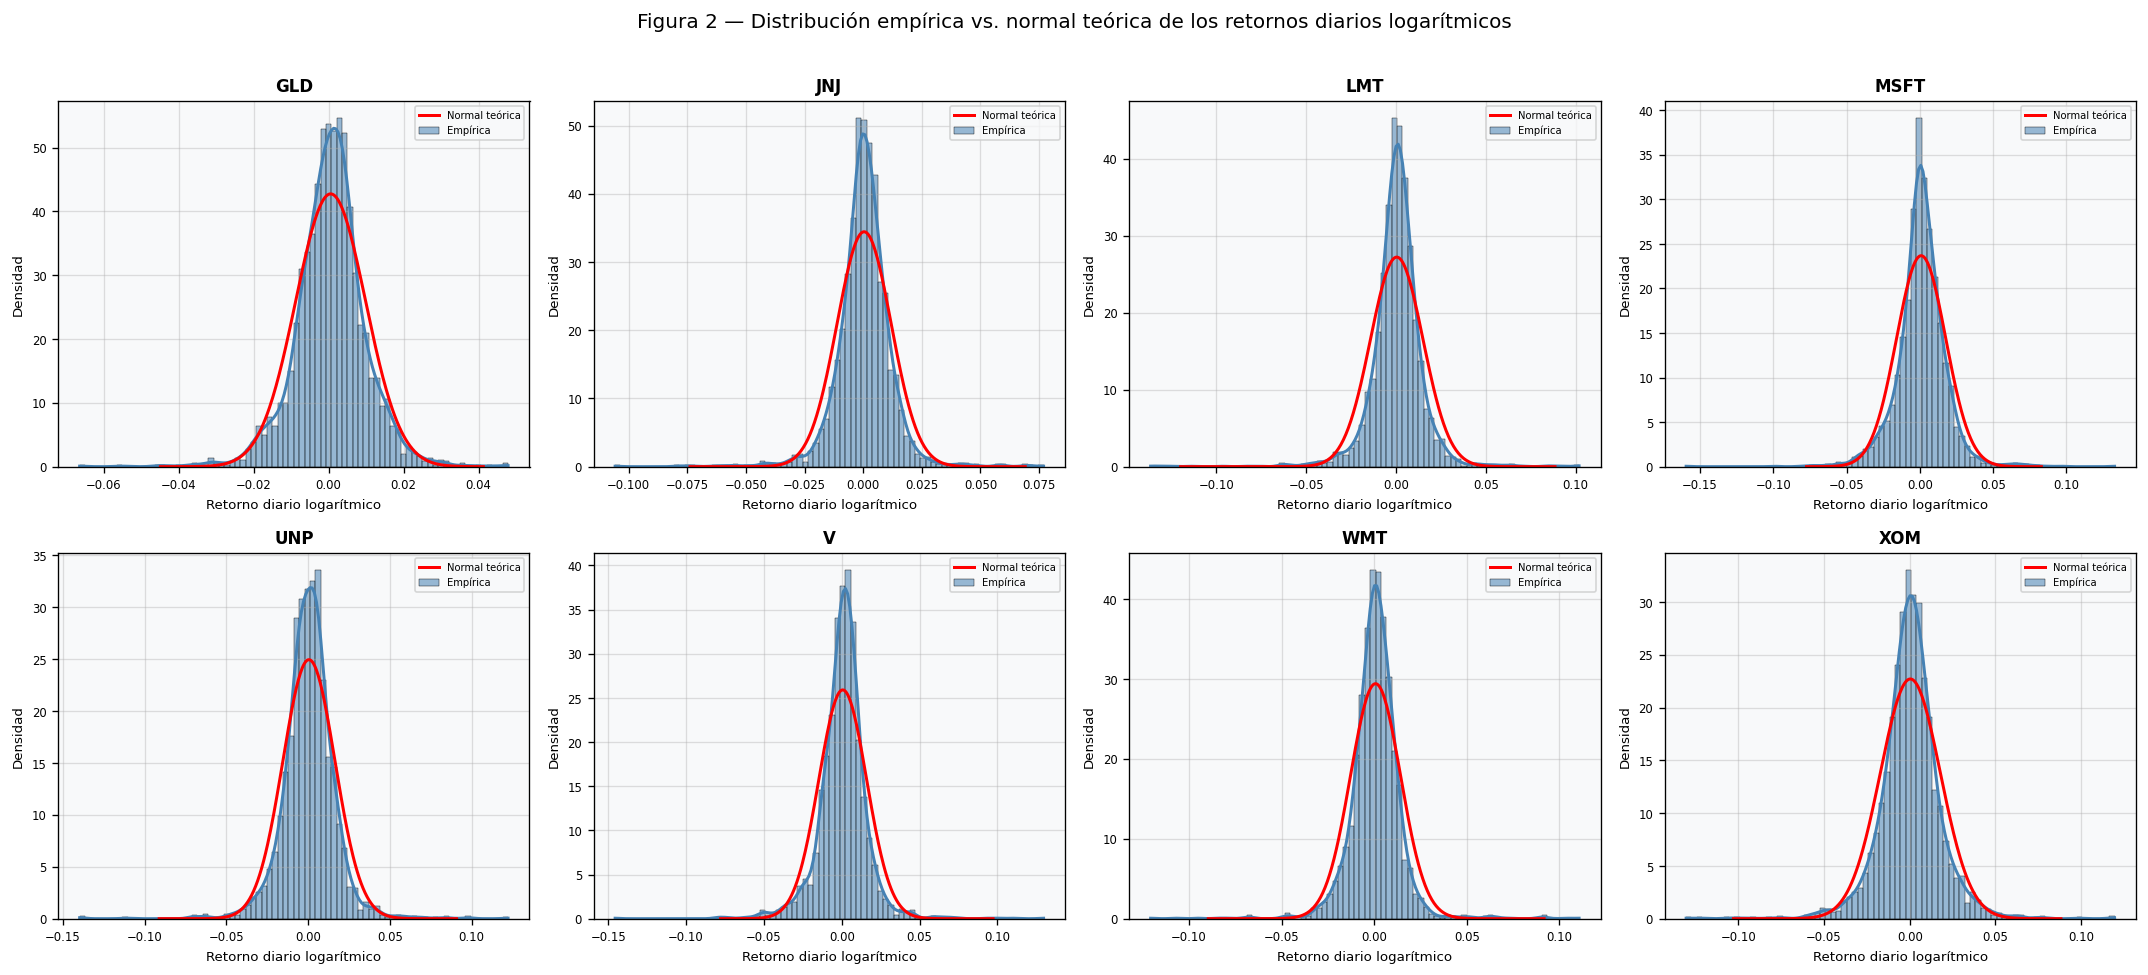


Figura 2 guardada.


In [6]:
# No-normalidad de los retornos: asimetría y colas pesadas
#
# En finanzas, los modelos basados en media-varianza suelen interpretarse mejor
# cuando los retornos son aproximadamente normales. Por ello, conviene verificar
# empíricamente si este supuesto es razonable para nuestra muestra.
#
# Analizamos tres medidas:
#   1. Asimetría (skewness): mide el grado de simetría de la distribución.
#      Un valor cercano a 0 indica mayor simetría.
#
#   2. Curtosis en exceso (excess kurtosis): mide el grosor de las colas.
#      Un valor positivo indica colas más pesadas que la normal y, por tanto,
#      mayor frecuencia de eventos extremos.
#
#   3. Test de Jarque-Bera: prueba formal de normalidad.
#      Hipótesis nula H0: la distribución es normal.

print("TEST DE NORMALIDAD DE LOS RETORNOS (Jarque-Bera)")
print("=" * 68)
print(f"{'Activo':<12} {'Asimetría':>12} {'Curtosis exc.':>14} {'p-valor JB':>12} {'Decisión':>14}")
print("-" * 68)

for activo in ACTIVOS:
    serie = returns_log[activo]
    skew = serie.skew()
    kurt = serie.kurt()   # Pandas reporta curtosis en exceso: normal → 0
    _, p_jb = sp_stats.jarque_bera(serie)

    decision = "No normal ***" if p_jb < 0.01 else ("No normal *" if p_jb < 0.05 else "Normal")
    print(f"{activo:<12} {skew:>12.4f} {kurt:>14.4f} {p_jb:>12.2e}  {decision:>14}")

print("\nInterpretación:")
print("  • Curtosis en exceso > 0 indica colas más pesadas que la normal,")
print("    es decir, una mayor frecuencia de retornos extremos.")
print("  • Asimetría negativa sugiere una cola izquierda relativamente más larga,")
print("    asociada a caídas extremas más pronunciadas.")
print("  • En nuestra muestra, la mayoría de los activos rechazan normalidad,")
print("    lo que evidencia limitaciones de un enfoque basado solo en media y varianza")
print("    para describir adecuadamente el riesgo de cola.")

# ─── Figura 2: distribución empírica vs. normal teórica ───
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, activo in enumerate(ACTIVOS):
    mu_a = returns_log[activo].mean()
    sg_a = returns_log[activo].std()

    x_r = np.linspace(
        returns_log[activo].quantile(0.001),
        returns_log[activo].quantile(0.999),
        300
    )
    pdf_n = sp_stats.norm.pdf(x_r, mu_a, sg_a)

    sns.histplot(
        returns_log[activo], bins=80, kde=True, stat='density',
        color='steelblue', alpha=0.55, ax=axes[i], label='Empírica'
    )
    axes[i].plot(x_r, pdf_n, 'r-', linewidth=1.8, label='Normal teórica')
    axes[i].set_title(activo, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Retorno diario logarítmico', fontsize=8)
    axes[i].set_ylabel('Densidad', fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].legend(fontsize=6)

plt.suptitle(
    'Figura 2 — Distribución empírica vs. normal teórica de los retornos diarios logarítmicos',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('fig2_normalidad.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nFigura 2 guardada.")

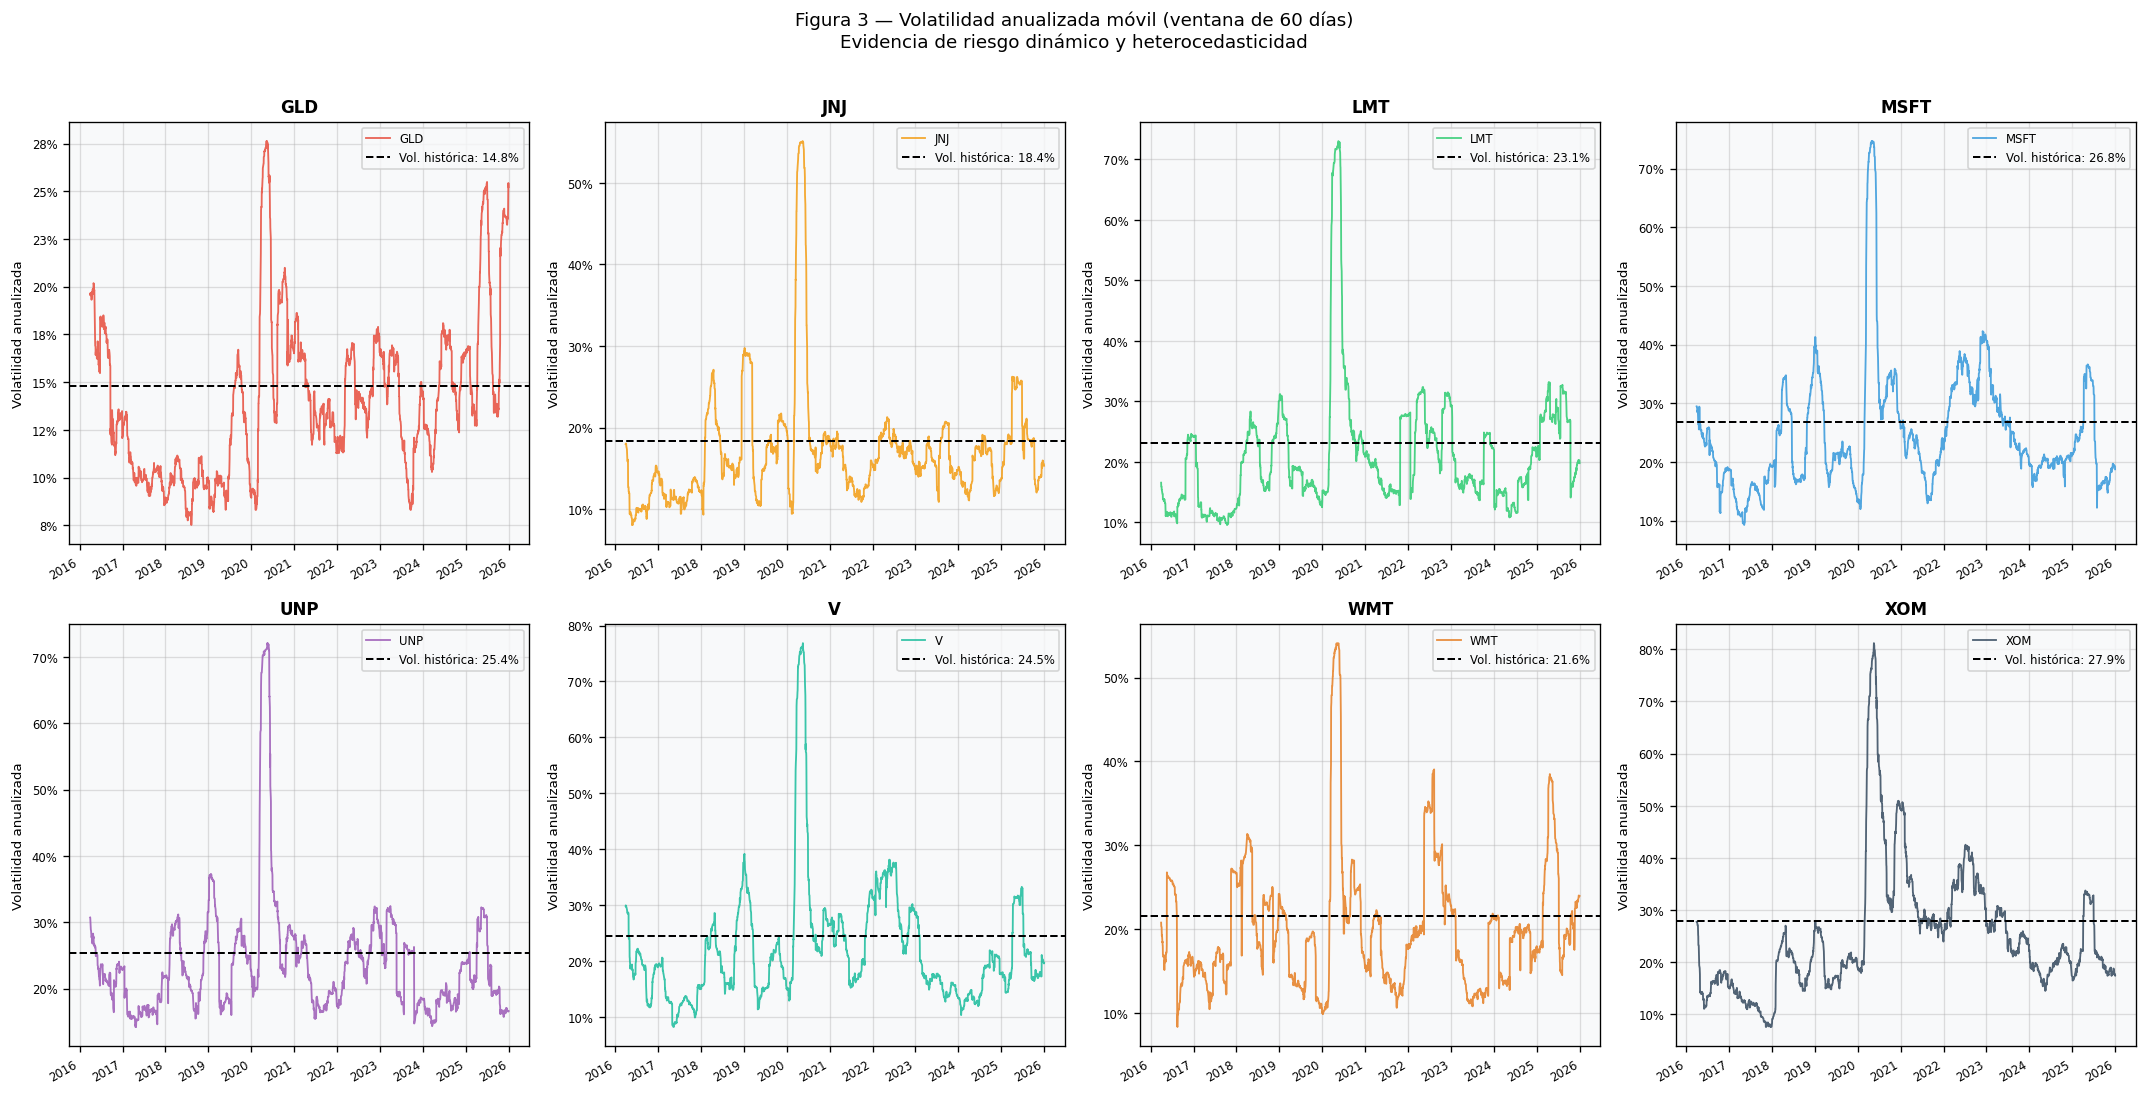

Figura 3 guardada.

Observaciones cualitativas:
  • Se observan episodios de volatilidad elevada seguidos por periodos de calma relativa.
  • Esto sugiere clustering de volatilidad: el riesgo no permanece constante en el tiempo.
  • Destacan eventos de estrés de mercado como 2020 (COVID-19) y 2022 (alzas de tasas).


In [7]:
# Análisis dinámico del riesgo: volatilidad en ventanas móviles
#
# El enfoque clásico de Markowitz utiliza una matriz de covarianza estática,
# por lo que no modela explícitamente la evolución temporal del riesgo.
# Para explorar esta limitación, analizamos la volatilidad con ventanas móviles.
#
# Si la volatilidad fuera aproximadamente estable, la serie rolling sería relativamente plana.
# En cambio, si observamos cambios persistentes o agrupamiento de episodios de alta volatilidad,
# esto sugiere heterocedasticidad y clustering de volatilidad, fenómenos comunes en finanzas.
#
# Usamos una ventana de 60 días bursátiles (~3 meses), que permite capturar
# variaciones de corto y mediano plazo sin perder demasiadas observaciones.

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
axes = axes.flatten()

colors_roll = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db',
               '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

for i, activo in enumerate(ACTIVOS):
    # Volatilidad rolling anualizada = std(60 días) × √252
    #
    # Aquí usamos retornos simples (pct_change), lo cual es una práctica común
    # en mediciones de volatilidad de corto plazo. Para retornos diarios, la diferencia
    # respecto a log-retornos suele ser pequeña.
    vol_roll = returns_simple[activo].rolling(window=60).std() * np.sqrt(TRADING_DAYS)

    # Volatilidad histórica anualizada de toda la muestra
    vol_hist = returns_simple[activo].std() * np.sqrt(TRADING_DAYS)

    vol_roll.plot(ax=axes[i], color=colors_roll[i], linewidth=1.1, alpha=0.85)
    axes[i].axhline(
        vol_hist, color='black', linestyle='--', linewidth=1.2,
        label=f'Vol. histórica: {vol_hist:.1%}'
    )

    axes[i].set_title(activo, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Volatilidad anualizada', fontsize=8)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))

plt.suptitle(
    'Figura 3 — Volatilidad anualizada móvil (ventana de 60 días)\n'
    'Evidencia de riesgo dinámico y heterocedasticidad',
    fontsize=11, y=1.01
)

plt.tight_layout()
plt.savefig('fig3_rolling_vol.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figura 3 guardada.")
print("\nObservaciones cualitativas:")
print("  • Se observan episodios de volatilidad elevada seguidos por periodos de calma relativa.")
print("  • Esto sugiere clustering de volatilidad: el riesgo no permanece constante en el tiempo.")
print("  • Destacan eventos de estrés de mercado como 2020 (COVID-19) y 2022 (alzas de tasas).")

### Funciones Propias del Equipo

In [8]:
# FUNCIÓN PROPIA 1: calcular_metricas_portafolio
#
# Calcula las tres métricas principales de un portafolio:
#
#   Retorno esperado : E[Rp] = w'μ
#   Volatilidad      : σp = √(w'Σw)
#   Ratio de Sharpe  : SR = (E[Rp] − Rf) / σp

def calcular_metricas_portafolio(pesos, mu, cov, rf=RF_ANUAL):
    """
    Calcula retorno esperado, volatilidad y Ratio de Sharpe de un portafolio.

    Parámetros
    ----------
    pesos : array-like, shape (N,)
        Vector de pesos del portafolio.
    mu : pd.Series, shape (N,)
        Retornos esperados anualizados de cada activo.
    cov : pd.DataFrame, shape (N, N)
        Matriz de covarianza anualizada.
    rf : float
        Tasa libre de riesgo anualizada.

    Retorna
    -------
    retorno : float
        Retorno esperado anualizado del portafolio.
    volatilidad : float
        Volatilidad anualizada del portafolio.
    sharpe : float
        Ratio de Sharpe anualizado.
    """
    pesos = np.asarray(pesos, dtype=float)

    retorno = float(pesos @ mu.values)
    varianza = float(pesos @ cov.values @ pesos)
    volatilidad = np.sqrt(max(varianza, 0.0))

    sharpe = (retorno - rf) / volatilidad if volatilidad > 1e-10 else 0.0

    return retorno, volatilidad, sharpe


# ─── Verificación con portafolio equi-ponderado ───
pesos_equi = np.ones(N) / N
ret_eq, vol_eq, sr_eq = calcular_metricas_portafolio(pesos_equi, mu_anual, cov_anual)

print(f"VERIFICACIÓN — Portafolio Equi-ponderado (1/N = {1/N:.2%} cada activo)")
print("=" * 58)
print(f"  Pesos          : {np.round(pesos_equi, 3)}")
print(f"  Retorno anual  : {ret_eq:.4%}")
print(f"  Volatilidad    : {vol_eq:.4%}")
print(f"  Ratio de Sharpe: {sr_eq:.4f}")

VERIFICACIÓN — Portafolio Equi-ponderado (1/N = 12.50% cada activo)
  Pesos          : [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
  Retorno anual  : 16.9779%
  Volatilidad    : 14.2818%
  Ratio de Sharpe: 0.8856


In [9]:
# Simulación Monte Carlo: Espacio de Portafolios Factibles (el más caro)
# 
# Generamos 20,000 portafolios aleatorios para aproximar visualmente el conjunto
# factible: las combinaciones riesgo-rendimiento alcanzables al variar los pesos
# entre los activos seleccionados.
#
# La "bala de Markowitz" es la nube de portafolios generada por distintas
# combinaciones de pesos. La frontera eficiente corresponde a la parte superior
# de la envolvente: para un mismo nivel de riesgo, no existe otro portafolio con
# mayor retorno esperado.
#
# Monte Carlo es útil como herramienta visual, pero no es un método exacto de
# optimización: solo muestrea el espacio de soluciones. La frontera eficiente
# se calcula en la siguiente celda mediante optimización cuadrática.

N_SIM = 20_000
np.random.seed(42)   # Semilla para reproducibilidad

sim_ret = np.zeros(N_SIM)
sim_vol = np.zeros(N_SIM)
sim_sr = np.zeros(N_SIM)
sim_pesos = np.zeros((N_SIM, N))

for i in range(N_SIM):
    # Dirichlet(1,...,1) genera puntos uniformemente distribuidos
    # sobre el simplex de pesos long-only.
    w = np.random.dirichlet(np.ones(N))

    r, v, s = calcular_metricas_portafolio(w, mu_anual, cov_anual)

    sim_ret[i] = r
    sim_vol[i] = v
    sim_sr[i] = s
    sim_pesos[i] = w

print(f"Monte Carlo completado: {N_SIM:,} portafolios simulados.")
print(f"  Rango de retornos     : [{sim_ret.min():.2%}, {sim_ret.max():.2%}]")
print(f"  Rango de volatilidades: [{sim_vol.min():.2%}, {sim_vol.max():.2%}]")
print(f"  Sharpe máximo (MC)    : {sim_sr.max():.4f}  (portafolio #{sim_sr.argmax():,})")
print(f"  Sharpe mínimo (MC)    : {sim_sr.min():.4f}  (portafolio #{sim_sr.argmin():,})")

Monte Carlo completado: 20,000 portafolios simulados.
  Rango de retornos     : [12.51%, 23.99%]
  Rango de volatilidades: [10.82%, 22.40%]
  Sharpe máximo (MC)    : 1.1605  (portafolio #8,313)
  Sharpe mínimo (MC)    : 0.3913  (portafolio #1,022)


In [10]:
# FUNCIÓN PROPIA 2: construir_frontera_eficiente
# 
# Esta función calcula numéricamente la frontera de mínima varianza de Markowitz.
# Para distintos retornos objetivo μ*, resuelve:
#
#     min   w' · Σ · w              (minimizar varianza del portafolio)
#     s.a.  w' · μ = μ*            (restricción de retorno objetivo)
#           Σ wᵢ = 1                (los pesos deben sumar 1)
#           wᵢ ≥ 0                  (sin ventas en corto — long-only)
#
# La parte eficiente de la frontera corresponde a los portafolios con retorno
# mayor o igual al retorno del portafolio de mínima varianza.

def construir_frontera_eficiente(mu, cov, n_puntos=200, rf=RF_ANUAL):
    """
    Calcula numéricamente la frontera de mínima varianza de Markowitz.

    Parámetros
    ----------
    mu : pd.Series
        Retornos esperados anualizados.
    cov : pd.DataFrame
        Matriz de covarianza anualizada.
    n_puntos : int
        Número de retornos objetivo evaluados.
    rf : float
        Tasa libre de riesgo anualizada.

    Retorna
    -------
    pd.DataFrame
        Tabla con columnas: Retorno, Volatilidad, Sharpe y Pesos.
    """
    n = len(mu)

    def var_port(w):
        return float(w @ cov.values @ w)

    restr_suma = {"type": "eq", "fun": lambda w: w.sum() - 1.0}
    bounds = [(0.0, 1.0)] * n

    # En un portafolio long-only, los retornos factibles están entre
    # min(μ) y max(μ). Usamos un margen pequeño para evitar problemas
    # numéricos en los extremos.
    ret_min = mu.min()
    ret_max = mu.max()
    margen = 1e-4 * (ret_max - ret_min)

    targets = np.linspace(ret_min + margen, ret_max - margen, n_puntos)

    w0 = np.ones(n) / n
    resultados = []

    for mu_obj in targets:
        restr_ret = {
            "type": "eq",
            "fun": lambda w, t=mu_obj: float(w @ mu.values) - t
        }

        res = minimize(
            var_port,
            w0,
            method="SLSQP",
            bounds=bounds,
            constraints=[restr_suma, restr_ret],
            options={"ftol": 1e-12, "maxiter": 1500, "disp": False}
        )

        if res.success:
            r, v, s = calcular_metricas_portafolio(res.x, mu, cov, rf)

            resultados.append({
                "Retorno": r,
                "Volatilidad": v,
                "Sharpe": s,
                "Pesos": res.x
            })

            # La solución anterior suele ser un buen punto inicial
            # para el siguiente retorno objetivo.
            w0 = res.x

    return pd.DataFrame(resultados)


def calcular_mvp(mu, cov, rf=RF_ANUAL):
    """
    Calcula el portafolio de mínima varianza global con restricciones long-only.

    Parámetros
    ----------
    mu : pd.Series
        Retornos esperados anualizados.
    cov : pd.DataFrame
        Matriz de covarianza anualizada.
    rf : float
        Tasa libre de riesgo anualizada.

    Retorna
    -------
    dict
        Diccionario con Retorno, Volatilidad, Sharpe y Pesos.
    """
    n = len(mu)

    def var_port(w):
        return float(w @ cov.values @ w)

    restr_suma = {"type": "eq", "fun": lambda w: w.sum() - 1.0}
    bounds = [(0.0, 1.0)] * n
    w0 = np.ones(n) / n

    res = minimize(
        var_port,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=[restr_suma],
        options={"ftol": 1e-12, "maxiter": 1500, "disp": False}
    )

    if not res.success:
        raise RuntimeError("No se pudo calcular el portafolio de mínima varianza.")

    r, v, s = calcular_metricas_portafolio(res.x, mu, cov, rf)

    return {
        "Retorno": r,
        "Volatilidad": v,
        "Sharpe": s,
        "Pesos": res.x
    }


# ─── Calculamos la frontera de mínima varianza ───

print("Calculando la frontera de mínima varianza...")
frontera = construir_frontera_eficiente(mu_anual, cov_anual, n_puntos=200)

print(f"Puntos calculados exitosamente: {len(frontera)}/200")


# ─── Calculamos el portafolio de mínima varianza global ───

mvp = calcular_mvp(mu_anual, cov_anual)

print("\nPORTAFOLIO DE MÍNIMA VARIANZA (MVP):")
print(f"  Retorno anual    : {mvp['Retorno']:.4%}")
print(f"  Volatilidad anual: {mvp['Volatilidad']:.4%}")
print(f"  Ratio de Sharpe  : {mvp['Sharpe']:.4f}")
print("  Composición:")

for activo, peso in zip(ACTIVOS, mvp["Pesos"]):
    if peso > 0.001:
        print(f"    {activo:<12}: {peso:.3%}")

Calculando la frontera de mínima varianza...
Puntos calculados exitosamente: 200/200

PORTAFOLIO DE MÍNIMA VARIANZA (MVP):
  Retorno anual    : 15.1962%
  Volatilidad anual: 10.7816%
  Ratio de Sharpe  : 1.0078
  Composición:
    GLD         : 50.152%
    JNJ         : 18.935%
    LMT         : 5.663%
    MSFT        : 2.163%
    UNP         : 5.849%
    V           : 2.845%
    WMT         : 11.572%
    XOM         : 2.820%


In [14]:
# FUNCIÓN PROPIA 3: maximizar_sharpe_ratio
#
# Esta función calcula la cartera de tangencia, es decir, el portafolio que
# maximiza el Ratio de Sharpe:
#
#     SR = (E[Rp] − Rf) / σp
#
# Geométricamente, corresponde al punto de tangencia entre la Línea de
# Asignación de Capital (CAL), que parte de Rf, y la frontera eficiente.
#
# Bajo los supuestos del CAPM, la cartera de mercado es la cartera tangente.
# En este proyecto comparamos nuestra cartera tangente empírica con el benchmark
# de mercado seleccionado.

def maximizar_sharpe_ratio(mu, cov, rf=RF_ANUAL):
    """
    Calcula la cartera de tangencia maximizando el Ratio de Sharpe.

    Parámetros
    ----------
    mu : pd.Series
        Retornos esperados anualizados de los activos.
    cov : pd.DataFrame
        Matriz de covarianza anualizada.
    rf : float
        Tasa libre de riesgo anualizada.

    Retorna
    -------
    pesos : np.ndarray
        Pesos óptimos del portafolio de tangencia.
    sharpe_max : float
        Ratio de Sharpe máximo alcanzado.
    """
    n = len(mu)

    def neg_sharpe(w):
        r, v, _ = calcular_metricas_portafolio(w, mu, cov, rf)
        return -(r - rf) / v if v > 1e-10 else 1e6

    restricciones = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
    bounds = [(0.0, 1.0)] * n
    w0 = np.ones(n) / n

    res = minimize(
        neg_sharpe,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=restricciones,
        options={"ftol": 1e-12, "maxiter": 3000, "disp": False}
    )

    if not res.success:
        print(f"Advertencia: {res.message}")

    return res.x, float(-res.fun)


# ─── Calculamos la cartera de tangencia ───

pesos_tang, sr_tang = maximizar_sharpe_ratio(mu_anual, cov_anual, RF_ANUAL)

ret_tang, vol_tang, _ = calcular_metricas_portafolio(
    pesos_tang, mu_anual, cov_anual, RF_ANUAL
)

print("CARTERA DE TANGENCIA (Máximo Ratio de Sharpe)")
print("=" * 55)
print(f"  Ratio de Sharpe        : {sr_tang:.4f}")
print(f"  Retorno esperado anual : {ret_tang:.4%}")
print(f"  Volatilidad anual      : {vol_tang:.4%}")
print(f"  Prima de riesgo        : {ret_tang - RF_ANUAL:.4%}")

print("\n  Composición óptima:")

for activo, peso in zip(ACTIVOS, pesos_tang):
    peso_limpio = 0.0 if abs(peso) < 1e-10 else peso
    barra = "█" * int(peso_limpio * 40)
    print(f"    {activo:<12}: {peso_limpio:.4%}  {barra}")


CARTERA DE TANGENCIA (Máximo Ratio de Sharpe)
  Ratio de Sharpe        : 1.1850
  Retorno esperado anual : 19.1792%
  Volatilidad anual      : 12.5311%
  Prima de riesgo        : 14.8492%

  Composición óptima:
    GLD         : 46.1008%  ██████████████████
    JNJ         : 0.0000%  
    LMT         : 0.5272%  
    MSFT        : 23.2615%  █████████
    UNP         : 3.8260%  █
    V           : 1.6532%  
    WMT         : 24.6313%  █████████
    XOM         : 0.0000%  


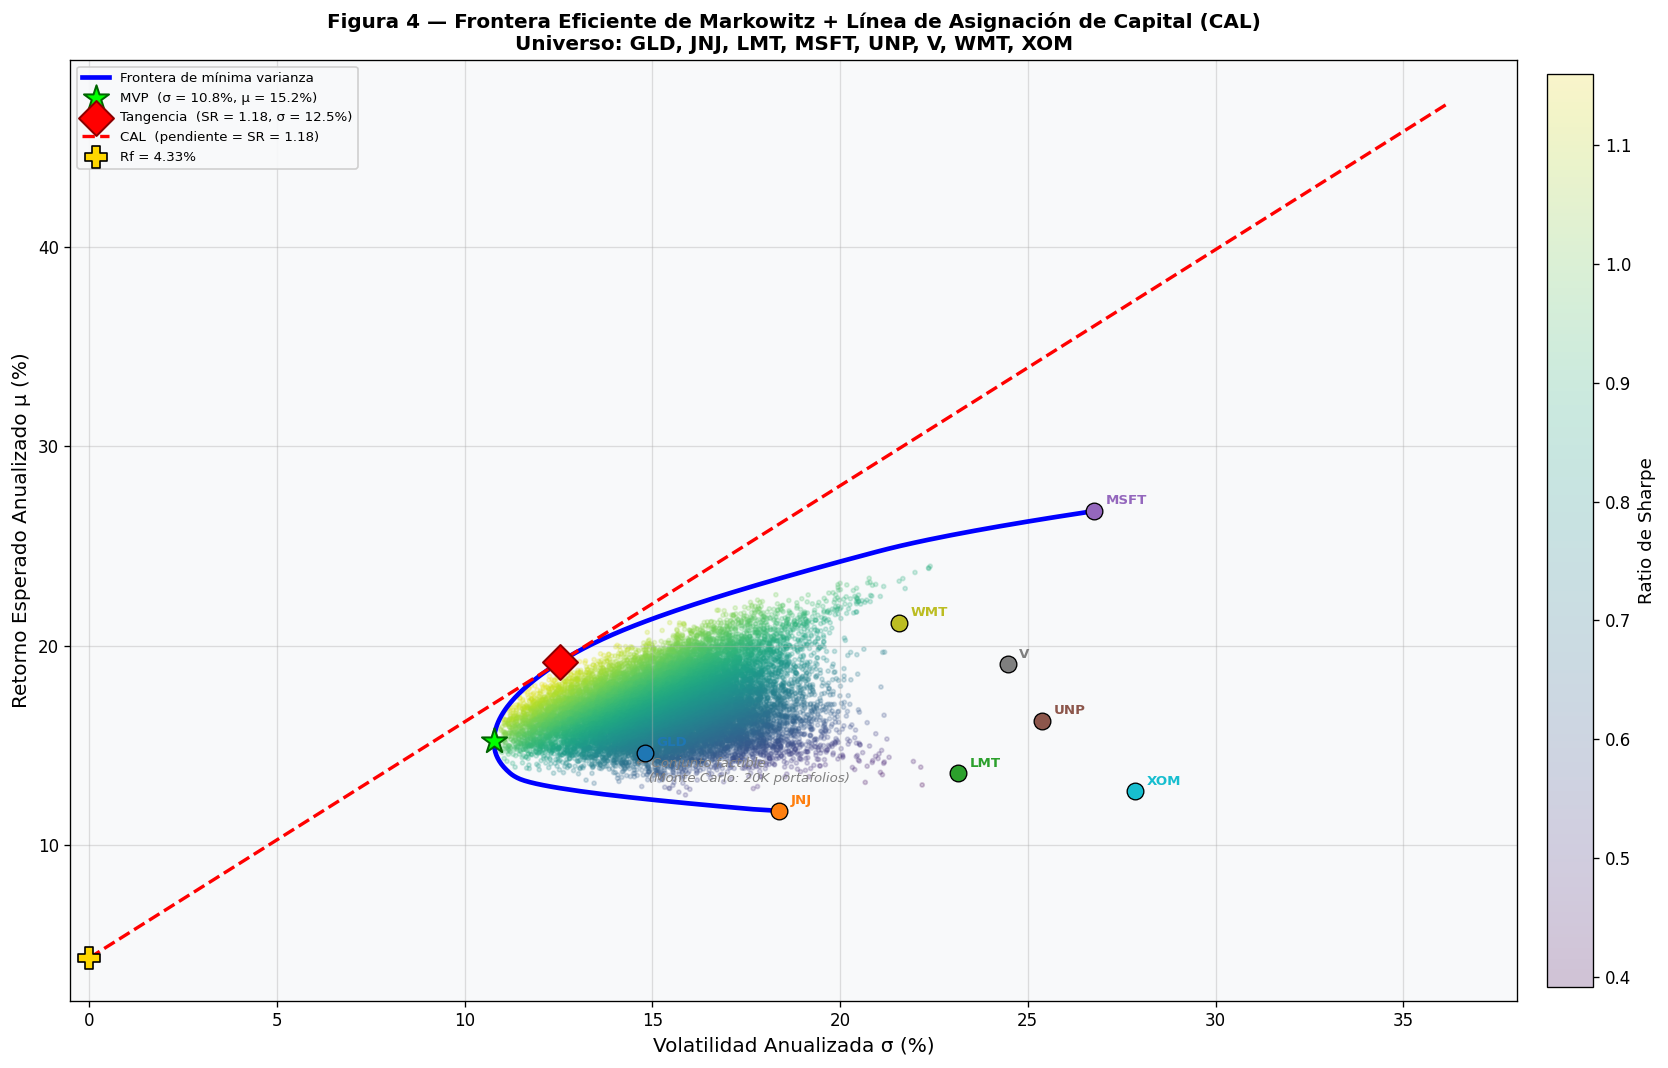

Figura 4 — Frontera Eficiente guardada.


In [13]:
# FASE 1: Gráfica de la Frontera Eficiente (Markowitz Bullet) + CAL
#
# Esta es la gráfica central del proyecto. Integra en un solo panel:
#   • La nube Monte Carlo (conjunto factible aproximado)
#   • La frontera de mínima varianza calculada por optimización
#   • El Portafolio de Mínima Varianza (MVP)
#   • La Cartera de Tangencia
#   • La Línea de Asignación de Capital (CAL)
#   • Los activos individuales

fig, ax = plt.subplots(figsize=(14, 9))

# 1. Nube Monte Carlo coloreada por Ratio de Sharpe
sc = ax.scatter(
    sim_vol * 100,
    sim_ret * 100,
    c=sim_sr,
    cmap='viridis',
    alpha=0.22,
    s=6,
    zorder=1
)

cbar = plt.colorbar(sc, ax=ax, label='Ratio de Sharpe', pad=0.02, fraction=0.03)

# 2. Frontera de mínima varianza
ax.plot(
    frontera['Volatilidad'] * 100,
    frontera['Retorno'] * 100,
    'b-',
    linewidth=2.8,
    zorder=4,
    label='Frontera de mínima varianza'
)

# 3. Portafolio de Mínima Varianza (MVP)
ax.scatter(
    mvp['Volatilidad'] * 100,
    mvp['Retorno'] * 100,
    color='lime',
    s=250,
    marker='*',
    zorder=7,
    edgecolors='darkgreen',
    linewidth=1.2,
    label=f'MVP  (σ = {mvp["Volatilidad"]:.1%}, μ = {mvp["Retorno"]:.1%})'
)

# 4. Cartera de Tangencia
ax.scatter(
    vol_tang * 100,
    ret_tang * 100,
    color='red',
    s=220,
    marker='D',
    zorder=7,
    edgecolors='darkred',
    linewidth=1.2,
    label=f'Tangencia  (SR = {sr_tang:.2f}, σ = {vol_tang:.1%})'
)

# 5. Activos individuales
colors_ind = plt.cm.tab10(np.linspace(0, 1, N))

for i, activo in enumerate(ACTIVOS):
    ax.scatter(
        sigma_anual[activo] * 100,
        mu_anual[activo] * 100,
        s=100,
        color=colors_ind[i],
        zorder=6,
        edgecolors='black',
        linewidth=0.8
    )

    ax.annotate(
        activo,
        (sigma_anual[activo] * 100, mu_anual[activo] * 100),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=8,
        fontweight='bold',
        color=colors_ind[i]
    )

# 6. Línea de Asignación de Capital (CAL)
#
# Fórmula en unidades decimales:
#     E[Rp_CAL] = Rf + SR_tangencia × σ
#
# Luego multiplicamos por 100 solo al graficar.
vol_cal_range = np.linspace(0, max(sigma_anual.max(), vol_tang) * 1.3, 300)
ret_cal_range = RF_ANUAL + sr_tang * vol_cal_range

ax.plot(
    vol_cal_range * 100,
    ret_cal_range * 100,
    'r--',
    linewidth=2.0,
    zorder=5,
    label=f'CAL  (pendiente = SR = {sr_tang:.2f})'
)

# 7. Punto Rf sobre el eje Y
ax.scatter(
    0,
    RF_ANUAL * 100,
    s=180,
    marker='P',
    color='gold',
    edgecolors='black',
    linewidth=1.0,
    zorder=7,
    label=f'Rf = {RF_ANUAL:.2%}'
)

ax.set_xlabel('Volatilidad Anualizada σ (%)', fontsize=12)
ax.set_ylabel('Retorno Esperado Anualizado μ (%)', fontsize=12)

ax.set_title(
    'Figura 4 — Frontera Eficiente de Markowitz + Línea de Asignación de Capital (CAL)\n'
    'Universo: GLD, JNJ, LMT, MSFT, UNP, V, WMT, XOM',
    fontsize=12,
    fontweight='bold'
)

ax.legend(loc='upper left', framealpha=0.92, fontsize=8)
ax.set_xlim(left=-0.5)

# Anotación explicativa
ax.annotate(
    '← Conjunto factible\n   (Monte Carlo: 20K portafolios)',
    xy=(sim_vol.max() * 100 * 0.65, sim_ret.min() * 100 * 1.05),
    fontsize=8,
    color='gray',
    style='italic'
)

plt.tight_layout()
plt.savefig('fig4_frontera_eficiente.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figura 4 — Frontera Eficiente guardada.")

---
## Fase 2 — CAPM y Cartera de Tangencia

In [15]:
# FASE 2: Estimación de Beta (β) y Modelo CAPM para todos los activos
# 
# El CAPM (Sharpe, 1964; Lintner, 1965) propone que el retorno esperado de un
# activo está LINEALMENTE relacionado con su riesgo sistemático (Beta):
#
#     E[Rᵢ] = Rf + βᵢ × (E[Rm] − Rf)
#
# Donde βᵢ = Cov(Rᵢ, Rm) / Var(Rm) se estima via regresión OLS de la forma:
#
#     Rᵢ − Rf = αᵢ + βᵢ(Rm − Rf) + εᵢ    (Modelo de mercado)
#
# Interpretación de Beta:
#   β > 1 → activo más volátil que el mercado (amplifica movimientos)
#   β < 1 → activo menos volátil que el mercado (amortigua movimientos)
#   β = 0 → activo sin correlación con el mercado (riesgo puramente idiosincrático)
#
# El Alfa de Jensen (αᵢ × 252 anualizado) mide el retorno ANORMAL:
#   α > 0 → activo subvaluado (supera al CAPM → valor para el inversionista)
#   α < 0 → activo sobrevaluado (no alcanza lo que exige el CAPM)

print("Estimando betas CAPM mediante regresión OLS diaria...")
print("=" * 75)

resultados_capm = {}
r2_adj_capm_daily = {}  # R² ajustado diario (Fase 2) — usado en la tabla final consolidada

for activo in ACTIVOS:
    # Excesos de retorno diario (Rᵢ − Rf y Rm − Rf)
    # Usamos RF_DIARIA_SIMPLE porque ret_activos y ret_mercado son
    # retornos simples; restar una Rf logarítmica sería inconsistente.
    exc_activo  = ret_activos[activo] - RF_DIARIA_SIMPLE
    exc_mercado = ret_mercado          - RF_DIARIA_SIMPLE

    # Regresión OLS: exc_activo = α + β × exc_mercado + ε
    X_capm = sm.add_constant(exc_mercado)
    modelo = sm.OLS(exc_activo, X_capm).fit()

    alpha_d    = modelo.params['const']
    beta_i     = modelo.params[BENCHMARK]
    r2_i       = modelo.rsquared_adj  # R² AJUSTADO (penaliza por los regresores)
    p_beta     = modelo.pvalues[BENCHMARK]
    ic_beta    = modelo.conf_int(alpha=0.05).loc[BENCHMARK]

    # Retorno requerido por CAPM (anualizado)
    ret_capm_i = RF_ANUAL + beta_i * (mu_mercado - RF_ANUAL)

    r2_adj_capm_daily[activo] = r2_i
    resultados_capm[activo] = {
        'Beta':           round(beta_i,  4),
        'IC_Beta_95_L':   round(ic_beta[0], 4),
        'IC_Beta_95_H':   round(ic_beta[1], 4),
        'p_valor_beta':   round(p_beta,  4),
        'Alpha_Anual':    round(alpha_d * TRADING_DAYS, 4),
        'R2_adj_diario':  round(r2_i,    4),  # R² ajustado con datos DIARIOS (Fase 2)
        'Retorno_CAPM':   round(ret_capm_i, 4),
        'Retorno_Hist':   round(mu_anual[activo], 4),
        'Diferencia':     round(mu_anual[activo] - ret_capm_i, 4),
    }
    sig_beta = '***' if p_beta < 0.01 else ('**' if p_beta < 0.05 else '*')
    print(f"  {activo:<12}: β={beta_i:.3f} {sig_beta}  IC95=[{ic_beta[0]:.3f},{ic_beta[1]:.3f}]"
          f"  α={alpha_d*252:.2%}  R²={r2_i:.3f}")

df_capm = pd.DataFrame(resultados_capm).T.astype(float)

print("\n" + "=" * 75)
print("TABLA RESUMEN CAPM")
print("=" * 75)
tabla_view = df_capm[['Beta', 'Alpha_Anual', 'R2_adj_diario', 'Retorno_CAPM', 'Retorno_Hist', 'Diferencia']].copy()
for col in ['Alpha_Anual', 'Retorno_CAPM', 'Retorno_Hist', 'Diferencia']:
    tabla_view[col] = tabla_view[col].map('{:.2%}'.format)
tabla_view['Beta'] = tabla_view['Beta'].map('{:.3f}'.format)
tabla_view['R2_adj_diario'] = tabla_view['R2_adj_diario'].map('{:.3f}'.format)
print(tabla_view.to_string())
print(f"\nRetorno anualizado del mercado (S&P 500): {mu_mercado:.4%}")


Estimando betas CAPM mediante regresión OLS diaria...
  GLD         : β=0.043 ***  IC95=[0.011,0.074]  α=9.88%  R²=0.002
  JNJ         : β=0.467 ***  IC95=[0.432,0.502]  α=2.90%  R²=0.212
  LMT         : β=0.561 ***  IC95=[0.516,0.606]  α=3.87%  R²=0.193
  MSFT        : β=1.181 ***  IC95=[1.146,1.215]  α=11.09%  R²=0.640
  UNP         : β=0.904 ***  IC95=[0.863,0.946]  α=3.24%  R²=0.417
  V           : β=1.025 ***  IC95=[0.990,1.059]  α=4.91%  R²=0.576
  WMT         : β=0.502 ***  IC95=[0.460,0.544]  α=11.99%  R²=0.177
  XOM         : β=0.804 ***  IC95=[0.753,0.856]  α=0.64%  R²=0.274

TABLA RESUMEN CAPM
       Beta Alpha_Anual R2_adj_diario Retorno_CAPM Retorno_Hist Diferencia
GLD   0.043       9.88%         0.002        4.74%       14.62%      9.88%
JNJ   0.467       2.90%         0.212        8.81%       11.71%      2.90%
LMT   0.561       3.87%         0.193        9.72%       13.59%      3.87%
MSFT  1.181      11.09%         0.640       15.66%       26.76%     11.09%
UNP   0.904  

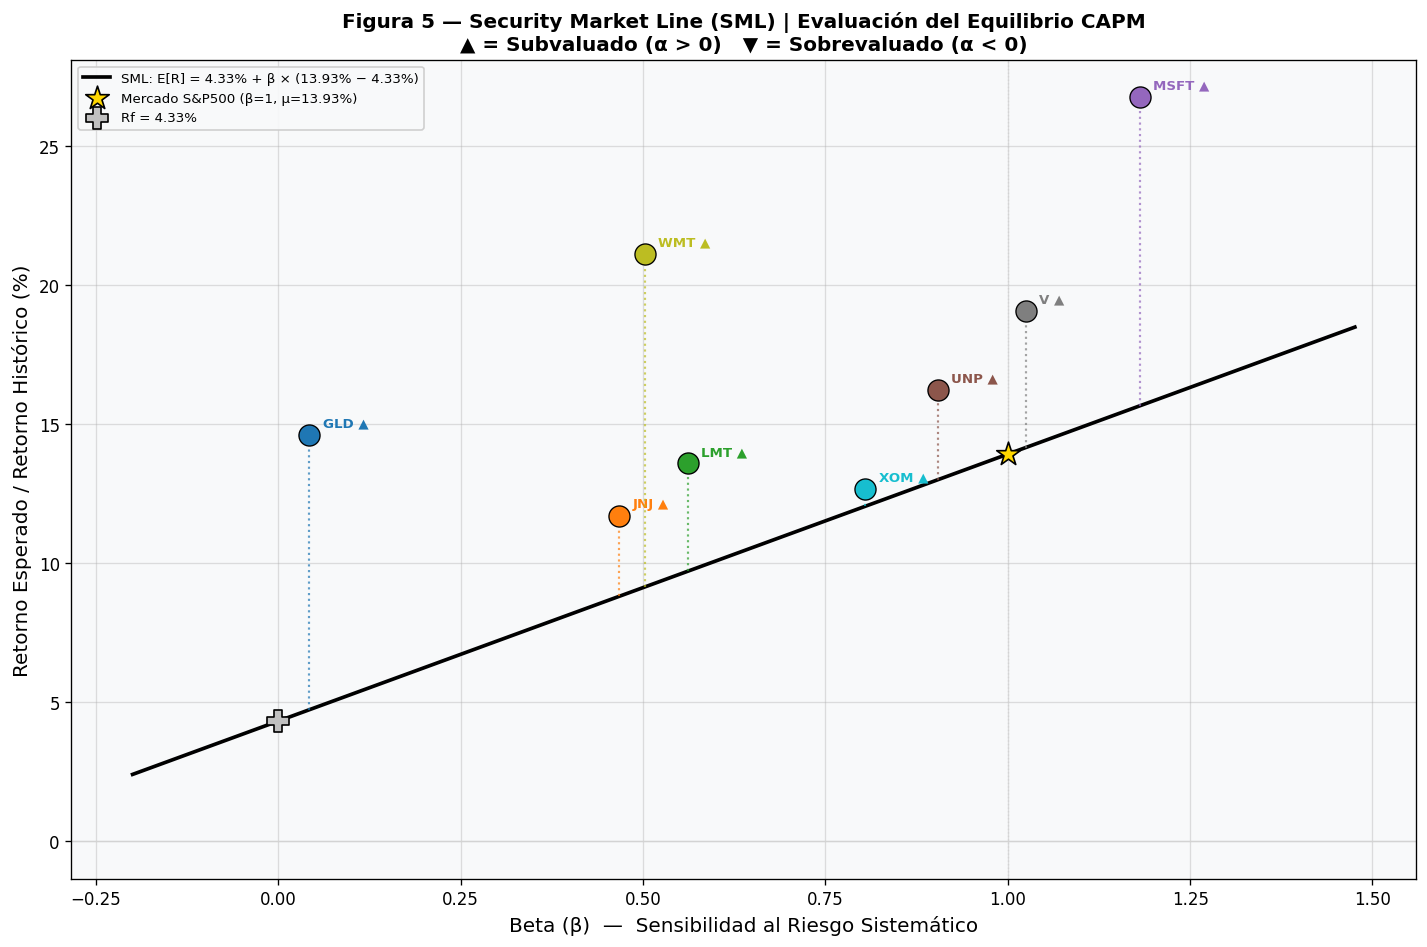

Figura 5 guardada.

  Activos subvaluados (α > 0) — generaron valor por encima del CAPM:
    ✅ GLD: α = 9.88% anual
    ✅ JNJ: α = 2.90% anual
    ✅ LMT: α = 3.87% anual
    ✅ MSFT: α = 11.09% anual
    ✅ UNP: α = 3.24% anual
    ✅ V: α = 4.91% anual
    ✅ WMT: α = 11.99% anual
    ✅ XOM: α = 0.64% anual

  Activos sobrevaluados (α < 0) — no alcanzaron el retorno exigido por el CAPM:


In [16]:
# FASE 2: Security Market Line (SML) y evaluación de equilibrio
# 
# La SML representa el locus de retornos requeridos por el CAPM en función de β.
# Si el mercado ESTÁ en equilibrio, todos los activos deberían estar SOBRE la SML.
#
# Desviaciones de la SML:
#   Activo SOBRE la SML (retorno histórico > CAPM): subvaluado → comprar señal
#   Activo BAJO la SML  (retorno histórico < CAPM): sobrevaluado → vender señal
#
# Limitación importante: el CAPM predice RETORNOS ESPERADOS, no históricos.
# Las desviaciones pueden deberse a: (a) riesgo no capturado, (b) error de
# estimación del β, o (c) genuina ineficiencia del mercado en ese periodo.

fig, ax = plt.subplots(figsize=(12, 8))

# ─── SML ───
beta_range    = np.linspace(-0.2, df_capm['Beta'].max() * 1.25, 300)
sml_ret_range = RF_ANUAL + beta_range * (mu_mercado - RF_ANUAL)
ax.plot(beta_range, sml_ret_range * 100, 'k-', linewidth=2.2, zorder=3,
        label=f'SML: E[R] = {RF_ANUAL:.2%} + β × ({mu_mercado:.2%} − {RF_ANUAL:.2%})')

# ─── Activos ───
colors_sml = plt.cm.tab10(np.linspace(0, 1, N))
for i, activo in enumerate(ACTIVOS):
    b_i    = df_capm.loc[activo, 'Beta']
    r_hist = df_capm.loc[activo, 'Retorno_Hist']
    r_capm = df_capm.loc[activo, 'Retorno_CAPM']

    # Punto observado (retorno histórico)
    ax.scatter(b_i, r_hist * 100, s=160, color=colors_sml[i],
               edgecolors='black', linewidth=0.8, zorder=6)

    # Línea punteada vertical → diferencia Alpha (retorno anormal)
    ax.plot([b_i, b_i], [r_capm * 100, r_hist * 100],
            ':', color=colors_sml[i], linewidth=1.3, alpha=0.7, zorder=4)

    # Etiqueta del activo (con dirección del Alpha)
    alpha_ann = df_capm.loc[activo, 'Alpha_Anual']
    signo = '▲' if alpha_ann > 0 else '▼'
    offset_y = 5 if r_hist > r_capm else -14
    ax.annotate(f"{activo} {signo}",
                (b_i, r_hist * 100),
                textcoords="offset points", xytext=(8, offset_y),
                fontsize=8, fontweight='bold', color=colors_sml[i])

# ─── Punto de mercado (β=1) y Rf (β=0) ───
ax.scatter(1.0, mu_mercado * 100, s=220, marker='*', color='gold',
           edgecolors='black', linewidth=1.0, zorder=7,
           label=f'Mercado S&P500 (β=1, μ={mu_mercado:.2%})')
ax.scatter(0.0, RF_ANUAL * 100, s=180, marker='P', color='silver',
           edgecolors='black', linewidth=1.0, zorder=7,
           label=f'Rf = {RF_ANUAL:.2%}')

ax.axhline(0, color='lightgray', linewidth=0.8)
ax.axvline(1, color='lightgray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Beta (β)  —  Sensibilidad al Riesgo Sistemático', fontsize=12)
ax.set_ylabel('Retorno Esperado / Retorno Histórico (%)', fontsize=12)
ax.set_title(
    'Figura 5 — Security Market Line (SML) | Evaluación del Equilibrio CAPM\n'
    '▲ = Subvaluado (α > 0)   ▼ = Sobrevaluado (α < 0)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper left', framealpha=0.92)

plt.tight_layout()
plt.savefig('fig5_sml.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figura 5 guardada.")
print("\n  Activos subvaluados (α > 0) — generaron valor por encima del CAPM:")
for a in ACTIVOS:
    if df_capm.loc[a, 'Alpha_Anual'] > 0:
        print(f"    ✅ {a}: α = {df_capm.loc[a,'Alpha_Anual']:.2%} anual")
print("\n  Activos sobrevaluados (α < 0) — no alcanzaron el retorno exigido por el CAPM:")
for a in ACTIVOS:
    if df_capm.loc[a, 'Alpha_Anual'] <= 0:
        print(f"    ❌ {a}: α = {df_capm.loc[a,'Alpha_Anual']:.2%} anual")


---
## Fase 3 — Arbitrage Pricing Theory (APT)

In [17]:
# FASE 3: Descarga y construcción de factores macroeconómicos (APT)
# 
# El modelo APT (Ross, 1976) generaliza el CAPM al proponer que los retornos
# dependen de MÚLTIPLES factores de riesgo sistemático, no solo del mercado.
#
# FACTORES SELECCIONADOS Y JUSTIFICACIÓN:
# ─────────────────────────────────────────────────────────────────────────────
# F1 — Mercado: Exceso de retorno del S&P 500 (factor dominante; hereda al CAPM)
#      Fuente: yfinance (^GSPC)
#
# F2 — Inflación: Cambio % mensual del Índice de Precios al Consumidor (CPI)
#      Fuente: API pública de FRED (serie CPIAUCSL) via requests
#      Justificación: la inflación erosiona los retornos reales. Sectores como
#      consumo básico (WMT) y energía (XOM) son sensibles a este factor.
#
# F3 — Tasa de interés LP: Cambio en el rendimiento del T-Note a 10 años
#      Fuente: API pública de FRED (serie DGS10) via requests
#      Justificación: los movimientos de tasas revalúan todos los activos de riesgo
#      (mayor tasa → mayor tasa de descuento → menor valor presente).
#
# F4 — Precio del petróleo: Cambio % mensual en el WTI (crudo americano)
#      Fuente: API pública de FRED (serie DCOILWTICO) via requests
#      Justificación: el petróleo afecta costos de producción y está directamente
#      vinculado a XOM; también es proxy de actividad económica global.
#
# COMPATIBILIDAD Python 3.14.5:
#   pandas_datareader NO es compatible con Python 3.12+ (requiere 'distutils',
#   eliminado del lenguaje). Solución: descargamos los datos directamente desde
#   la API REST pública de FRED usando 'requests', sin dependencias externas.
#   Prompt de IA utilizado: "¿Cuál es el endpoint REST de FRED para descargar
#   una serie como CPIAUCSL sin usar pandas_datareader en Python 3.14.5?"
#
# CORRECCIÓN DEL REZAGO DEL CPI:
#   La inflación (CPIAUCSL) se publica con aproximadamente un mes de rezago.
#   Si descargamos hoy, el mes más reciente tendrá NaN en CPI pero sí tendrá
#   datos de tasas y petróleo. Un dropna() directo eliminaría ese mes completo
#   de TODOS los activos, perdiendo observaciones innecesariamente.
#   Solución: aplicamos .ffill() ANTES del dropna(), propagando el último dato
#   disponible de CPI al mes actual. Esto preserva el último mes de datos.
#   Prompt de IA utilizado: "La inflación CPIAUCSL se publica con un mes de
#   rezago y me genera NaN en el último mes. ¿Cómo aplicar ffill antes del
#   dropna para no perder observaciones en la regresión APT?"

FRED_BASE = "https://api.stlouisfed.org/fred/series/observations"
# IMPORTANTE: La DEMO_KEY tiene un límite muy bajo (25 req/día por IP).
# Para garantizar la reproducibilidad al calificar, regístrese GRATIS en
# https://fred.stlouisfed.org/docs/api/api_key.html y reemplace DEMO_KEY:
FRED_KEY  = "DEMO_KEY"   # ← Reemplazar con su API key personal gratuita de FRED

def descargar_fred(serie_id, inicio=FECHA_INICIO, fin=FECHA_FIN):
    """
    Descarga una serie de FRED usando la API REST pública (sin pandas_datareader).
    Compatible con Python 3.14.5.
    
    Parámetros
    ----------
    serie_id : str — ID de la serie FRED (ej. 'CPIAUCSL', 'DGS10')
    inicio   : str — Fecha de inicio en formato YYYY-MM-DD
    fin      : str — Fecha de fin en formato YYYY-MM-DD
    
    Retorna
    -------
    pd.Series con índice DatetimeIndex y valores numéricos de la serie.
    """
    params = {
        "series_id":        serie_id,
        "observation_start": inicio,
        "observation_end":   fin,
        "api_key":           FRED_KEY,
        "file_type":         "json",
    }
    resp = requests.get(FRED_BASE, params=params, timeout=30)
    resp.raise_for_status()
    obs  = resp.json()["observations"]
    serie = pd.Series(
        {pd.Timestamp(o["date"]): float(o["value"]) if o["value"] != "." else float("nan")
         for o in obs},
        name=serie_id
    )
    return serie

print("Descargando factores macroeconómicos desde FRED (via requests)...")
fred_ok = False
try:
    cpi_raw   = descargar_fred('CPIAUCSL')
    dgs10_raw = descargar_fred('DGS10')
    wti_raw   = descargar_fred('DCOILWTICO')
    fred_ok = True
    print("  ✅ Datos de FRED descargados correctamente (sin pandas_datareader).")
except Exception as e:
    print(f"  ⚠️  FRED no disponible: {e}")
    print("  Usando factores alternativos desde Yahoo Finance (VIX y DXY).")

# ─── Retornos mensuales logarítmicos de los activos ───
# Los log-retornos mensuales = suma de log-retornos diarios del mes (propiedad de aditividad)
ret_monthly_full = np.log(df / df.shift(1)).dropna().resample('ME').sum()
ret_act_m = ret_monthly_full[ACTIVOS].copy()
ret_mkt_m = ret_monthly_full[BENCHMARK].copy()

# Factor 1 siempre disponible: exceso de retorno del mercado (mensual)
exc_mkt_m = ret_mkt_m - RF_MENSUAL
exc_mkt_m.name = 'F_Mercado'

if fred_ok:
    # ─── Factor 2: Inflación (CPI) ───
    # CORRECCIÓN REZAGO: aplicamos .ffill() ANTES de calcular el retorno logarítmico.
    # Esto rellena el NaN del mes más reciente con el dato del mes anterior,
    # evitando perder la última observación en el dropna() final.
    cpi_m  = cpi_raw.resample('ME').last().ffill()   # ← ffill ANTES del log-retorno
    f_infl = np.log(cpi_m / cpi_m.shift(1)).dropna()
    f_infl.name = 'F_Inflacion'

    # ─── Factor 3: Tasa de interés (T-Note 10Y) ───
    # Para tasas usamos diferencias en puntos porcentuales (no log-retorno),
    # porque la tasa ya está en porcentaje y puede ser cero o negativa.
    # También aplicamos ffill() para manejar días festivos y rezagos de publicación.
    dgs10_m = dgs10_raw.resample('ME').last().ffill()   # ← ffill para días sin dato
    f_tasa  = dgs10_m.diff().dropna()
    f_tasa.name = 'F_Tasa_LP'

    # ─── Factor 4: Petróleo WTI ───
    # ffill() maneja los días donde FRED no reporta precio (fines de semana, festivos)
    wti_m   = wti_raw.resample('ME').last().ffill()     # ← ffill para fechas faltantes
    f_wti   = np.log(wti_m / wti_m.shift(1)).dropna()
    f_wti.name = 'F_Petroleo'

    factores_df  = pd.concat([exc_mkt_m, f_infl, f_tasa, f_wti], axis=1)
    # NOTA: cada factor ya recibió su propio ffill() antes del concat. El ffill()
    # global aquí es solo un respaldo para el rezago residual del CPI. Al tener
    # todos los factores pre-rellenados, el riesgo de propagación cruzada es mínimo.
    # Se utiliza dropna() final para eliminar filas donde ningún ffill pudo ayudar.
    factores_df  = factores_df.ffill().dropna()
    factores_df.columns = ['F_Mercado', 'F_Inflacion', 'F_Tasa_LP', 'F_Petroleo']
    FACTOR_NAMES = ['F_Mercado', 'F_Inflacion', 'F_Tasa_LP', 'F_Petroleo']
    print("  Factores FRED: Mercado, Inflación CPI, Tasa LP (10Y), Petróleo WTI")

else:
    # Alternativa: descargar VIX (volatilidad) y DXY (dólar) desde Yahoo Finance
    vix_raw   = yf.download('^VIX', start=FECHA_INICIO, end=FECHA_FIN,
                             auto_adjust=True, progress=False)['Close']
    dxy_raw   = yf.download('DX-Y.NYB', start=FECHA_INICIO, end=FECHA_FIN,
                             auto_adjust=True, progress=False)['Close']
    if isinstance(vix_raw, pd.DataFrame): vix_raw = vix_raw.iloc[:, 0]
    if isinstance(dxy_raw, pd.DataFrame): dxy_raw = dxy_raw.iloc[:, 0]

    # NOTA APT — Shocks, no niveles: el APT requiere que los factores sean
    # "innovaciones" (cambios inesperados), no niveles brutos. VIX y DXY
    # exhiben raíces unitarias en niveles (regresión espuria). Al aplicar
    # np.log(...).resample().sum() obtenemos log-retornos mensuales acumulados,
    # que equivalen a primeras diferencias logarítmicas y eliminan la tendencia
    # estocástica. Esto garantiza que las series sean estacionarias y válidas
    # como regresores en el modelo APT (Ross, 1976).
    f_vix = np.log(vix_raw / vix_raw.shift(1)).resample('ME').sum().dropna()
    f_dxy = np.log(dxy_raw / dxy_raw.shift(1)).resample('ME').sum().dropna()
    f_vix.name = 'F_VIX'
    f_dxy.name = 'F_DXY'

    factores_df = pd.concat([exc_mkt_m, f_vix, f_dxy], axis=1).dropna()
    FACTOR_NAMES = ['F_Mercado', 'F_VIX', 'F_DXY']
    print("  Factores Yahoo: Mercado, VIX (volatilidad implícita), DXY (dólar)")

# ─── Alineamos activos con factores ───
exc_act_m = ret_act_m.subtract(RF_MENSUAL)   # Excesos de retorno mensuales de los activos
datos_apt = pd.merge(exc_act_m, factores_df, left_index=True, right_index=True, how='inner')

print(f"\nObservaciones para APT: {len(datos_apt)} meses")
print(f"Rango: {datos_apt.index[0].date()} — {datos_apt.index[-1].date()}")
print(f"\nEstadísticas descriptivas de los factores:")
print(datos_apt[FACTOR_NAMES].describe().round(5).to_string())


Descargando factores macroeconómicos desde FRED (via requests)...
  ⚠️  FRED no disponible: 400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=CPIAUCSL&observation_start=2016-01-01&observation_end=2026-01-01&api_key=DEMO_KEY&file_type=json
  Usando factores alternativos desde Yahoo Finance (VIX y DXY).
  Factores Yahoo: Mercado, VIX (volatilidad implícita), DXY (dólar)

Observaciones para APT: 120 meses
Rango: 2016-01-31 — 2025-12-31

Estadísticas descriptivas de los factores:
       F_Mercado      F_VIX      F_DXY
count  120.00000  120.00000  120.00000
mean     0.00667   -0.00271   -0.00005
std      0.04353    0.23235    0.01893
min     -0.13720   -0.61428   -0.05133
25%     -0.01230   -0.13939   -0.01365
50%      0.01421   -0.01562    0.00098
75%      0.03150    0.11932    0.01571
max      0.11589    0.75564    0.04621


In [18]:
# FASE 3: Regresiones APT por activo + contraste CAPM vs APT
# 
# Modelo APT:  Rᵢ − Rf = αᵢ + βᵢ₁F₁ + βᵢ₂F₂ + βᵢ₃F₃ + [βᵢ₄F₄] + εᵢ
#
# La pregunta central del proyecto es: ¿el APT tiene mayor poder explicativo que
# el CAPM? La métrica de comparación es el R² AJUSTADO, que penaliza por el número
# de regresores y permite comparar modelos con distinto número de variables.
#
# H₀: R²_adj(APT) ≤ R²_adj(CAPM)   → el APT no agrega valor explicativo
# H₁: R²_adj(APT) > R²_adj(CAPM)   → el APT tiene mayor poder explicativo

X_apt = sm.add_constant(datos_apt[FACTOR_NAMES])    # Matriz de regresores con intercepto
X_capm_m = sm.add_constant(datos_apt['F_Mercado'])  # Solo mercado (para comparación)

resultados_apt_dict = {}
r2_adj_capm = {}
r2_adj_apt  = {}

print("REGRESIONES APT — RESULTADOS COMPLETOS POR ACTIVO")
print("=" * 80)

for activo in ACTIVOS:
    y = datos_apt[activo]

    # ─── Modelo APT (multifactorial) ───
    modelo_apt  = sm.OLS(y, X_apt).fit()

    # ─── Modelo CAPM mensual (un factor) para comparación directa ───
    # NOTA: usamos datos MENSUALES en AMBOS modelos (CAPM y APT) para garantizar
    # consistencia. Las betas de la Fase 2 (estimadas diariamente) sirven para
    # la SML; aquí el R² mensual compara poder explicativo en la misma muestra.
    modelo_capm_m = sm.OLS(y, X_capm_m).fit()

    resultados_apt_dict[activo] = modelo_apt
    r2_adj_capm[activo] = modelo_capm_m.rsquared_adj
    r2_adj_apt[activo]  = modelo_apt.rsquared_adj

    print(f"\n{'─'*60}")
    print(f"  Activo: {activo}")
    print(f"  R² CAPM = {modelo_capm_m.rsquared_adj:.4f}   "
          f"R² APT (adj) = {modelo_apt.rsquared_adj:.4f}   "
          f"AIC = {modelo_apt.aic:.1f}")
    print(f"  {'Factor':<22} {'Coef.':>10} {'t-stat':>9} {'p-valor':>9} {'Sig.':>5}")
    print(f"  {'────────────────────':<22} {'─────':>10} {'──────':>9} {'───────':>9} {'────':>5}")
    for factor in FACTOR_NAMES:
        coef  = modelo_apt.params[factor]
        tstat = modelo_apt.tvalues[factor]
        pval  = modelo_apt.pvalues[factor]
        sig   = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        print(f"  {factor:<22} {coef:>10.4f} {tstat:>9.2f} {pval:>9.4f} {sig:>5}")

# ─── Tabla comparativa R² CAPM vs APT ───
comparacion_r2 = pd.DataFrame({
    'R² aj. CAPM': r2_adj_capm,
    'R² aj. APT':  r2_adj_apt,
})
comparacion_r2['Δ R²'] = comparacion_r2['R² aj. APT'] - comparacion_r2['R² aj. CAPM']
comparacion_r2['Mejora?'] = comparacion_r2['Δ R²'].apply(lambda x: '✅ APT mejor' if x > 0 else '❌ CAPM similar')

print("\n\n" + "=" * 65)
print("TABLA COMPARATIVA: R² AJUSTADO — CAPM vs. APT")
print("=" * 65)
print(comparacion_r2.round(4).to_string())
n_mejora = (comparacion_r2['Δ R²'] > 0).sum()
print(f"\nConclusión: El APT supera al CAPM en {n_mejora}/{N} activos.")
print(f"  Δ R² promedio: {comparacion_r2['Δ R²'].mean():+.4f}")
mejora_prom = comparacion_r2['Δ R²'].mean() * 100
if mejora_prom > 0:
    print(f"  → En promedio, el APT explica {mejora_prom:.2f} p.p. adicionales de varianza.")
else:
    print(f"  → El CAPM resulta comparable al APT para este universo de activos.")

# ─────────────────────────────────────────────────────────────────────────────
# PRUEBA ESTADÍSTICA FORMAL: H₀: R²_adj(APT) ≤ R²_adj(CAPM)
# ─────────────────────────────────────────────────────────────────────────────
# CAPM es un caso especial restringido del APT (APT con solo el factor de mercado).
# Son modelos ANIDADOS → se puede usar una prueba F exacta para cada activo.
# H₀: los factores adicionales (F_Inflacion, F_Tasa_LP, F_Petroleo) son conjuntamente
#     no significativos (sus coeficientes = 0).
# H₁: al menos un factor adicional es significativo.
#
# Si rechazamos H₀ (p < 0.05), el APT tiene significativamente mayor poder explicativo.

print("\n" + "=" * 80)
print("PRUEBA F FORMAL: CAPM (restringido) vs. APT (irrestricto) — Modelos Anidados")
print("=" * 80)
print(f"  H₀: Los factores adicionales del APT son conjuntamente NO significativos")
print(f"  H₁: Al menos un factor adicional mejora significativamente el modelo\n")
print(f"  {'Activo':<12} {'F-stat':>10} {'p-valor':>12} {'GL restr.':>10} {'Decisión':>22}")
print(f"  {'─────────':<12} {'──────':>10} {'────────':>12} {'─────────':>10} {'────────────────────':>22}")

factores_extra = [f for f in FACTOR_NAMES if f != 'F_Mercado']
n_restricciones = len(factores_extra)

for activo in ACTIVOS:
    modelo_apt_i = resultados_apt_dict[activo]
    # Construimos la matriz de restricciones: cada fila pone a cero un factor adicional
    restricciones = np.zeros((n_restricciones, len(modelo_apt_i.params)))
    for k, factor in enumerate(factores_extra):
        idx = list(modelo_apt_i.params.index).index(factor)
        restricciones[k, idx] = 1.0
    resultado_f = modelo_apt_i.f_test(restricciones)
    f_stat = float(resultado_f.fvalue)
    p_val  = float(resultado_f.pvalue)
    decision = "✅ APT sig. mejor (p<0.05)" if p_val < 0.05 else (
               "⚠️  APT mejor (p<0.10)"    if p_val < 0.10 else
               "❌ Sin mejora signif.")
    print(f"  {activo:<12} {f_stat:>10.3f} {p_val:>12.4f} {n_restricciones:>10} {decision:>22}")

print(f"\n  Nota: GL de restricciones = {n_restricciones} (factores adicionales del APT sobre el CAPM)")
print(f"  La prueba evalúa si la mejora en R² al añadir {n_restricciones} factores es estadísticamente significativa,")
print(f"  no solo un artefacto del muestreo.")

# ESTIMACIÓN DE PRIMAS DE RIESGO (λ) — Método de Fama-MacBeth (1973)
# 
# La ecuación APT es:  E[Rᵢ] = Rf + βᵢ₁λ₁ + βᵢ₂λ₂ + ... + βᵢₙλₙ
#
# Las β (sensibilidades) ya fueron estimadas en la primera etapa (regresión de
# series de tiempo). Ahora estimamos las λ (primas de riesgo) mediante una
# REGRESIÓN TRANSVERSAL (cross-sectional): para cada mes t, regresionamos los
# retornos en exceso de los activos sobre las β estimadas.
#
# Primera etapa  → β_ij = sensibilidad del activo i al factor j
# Segunda etapa  → λ_j  = prima de riesgo por unidad de exposición al factor j
#                          (cuánto compensa el mercado por cargar riesgo del factor j)
#
# Las λ se estiman como los promedios de los coeficientes de las regresiones
# transversales mensuales. Los errores estándar de Fama-MacBeth corrigen por
# la variación temporal de esas estimaciones.

print("\n" + "=" * 80)
print("ESTIMACIÓN FAMA-MACBETH: PRIMAS DE RIESGO POR FACTOR (λ)")
print("=" * 80)

# Matriz de betas estimadas (N activos × K factores)
# Se construye aquí para no depender de la celda de visualizaciones.
betas_fm = pd.DataFrame(
    {activo: resultados_apt_dict[activo].params[FACTOR_NAMES] for activo in ACTIVOS}
).T
betas_fm.columns = FACTOR_NAMES

# Retornos mensuales en exceso de los activos (alineados con el periodo APT)
ret_exceso_m = datos_apt[ACTIVOS].copy()

# Segunda etapa: para cada mes, regresión transversal retorno_exceso_i ~ β_i
lambdas_tiempo = []
for fecha in ret_exceso_m.index:
    y_cross = ret_exceso_m.loc[fecha]           # Retorno mensual en exceso (N activos,)
    X_cross  = sm.add_constant(betas_fm)        # Betas como regresores (N × K+1)
    try:
        modelo_cross = sm.OLS(y_cross, X_cross).fit()
        lambdas_tiempo.append(modelo_cross.params[FACTOR_NAMES].values)
    except Exception:
        pass

lambdas_df = pd.DataFrame(lambdas_tiempo, columns=FACTOR_NAMES)
lambda_prom = lambdas_df.mean()
lambda_std  = lambdas_df.std() / np.sqrt(len(lambdas_df))  # Error estándar Fama-MacBeth  
lambda_t    = lambda_prom / lambda_std                       # t-estadístico
# Wrap back into a Series so we can index by factor name (sp_stats.t.cdf drops the pandas index)
lambda_p    = pd.Series(
    2 * (1 - sp_stats.t.cdf(np.abs(lambda_t.values), df=len(lambdas_df)-1)),
    index=FACTOR_NAMES
)

print(f"\n  Periodo: {ret_exceso_m.index[0].date()} — {ret_exceso_m.index[-1].date()}")
print(f"  Observaciones mensuales (T): {len(lambdas_df)}")
print(f"  Activos (N): {N}\n")
print(f"  {'Factor':<22} {'λ mensual':>12} {'λ anual':>12} {'t-stat':>10} {'p-valor':>10} {'Sig.':>6}")
print(f"  {'─'*22} {'─'*12} {'─'*12} {'─'*10} {'─'*10} {'─'*6}")
for factor in FACTOR_NAMES:
    lm  = lambda_prom[factor]
    la  = lm * 12
    t   = lambda_t[factor]
    p   = lambda_p[factor]
    sig = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
    print(f"  {factor:<22} {lm:>12.5f} {la:>12.4f} {t:>10.3f} {p:>10.4f} {sig:>6}")

print("\nInterpretación de las primas de riesgo (λ):")
print("  λ > 0: el mercado PREMIA la exposición a este factor (mayor β → mayor retorno esperado)")
print("  λ < 0: el mercado CASTIGA la exposición (activos que 'cubren' este riesgo son costosos)")
print("  λ ≈ 0: el factor no tiene precio de riesgo en este universo/periodo")
print("  *** p<0.01  ** p<0.05  * p<0.10")


REGRESIONES APT — RESULTADOS COMPLETOS POR ACTIVO

────────────────────────────────────────────────────────────
  Activo: GLD
  R² CAPM = 0.0003   R² APT (adj) = 0.2906   AIC = -468.0
  Factor                      Coef.    t-stat   p-valor  Sig.
  ────────────────────        ─────    ──────   ───────  ────
  F_Mercado                  0.0506      0.46    0.6438      
  F_VIX                      0.0403      2.02    0.0460    **
  F_DXY                     -1.2199     -6.90    0.0000   ***

────────────────────────────────────────────────────────────
  Activo: JNJ
  R² CAPM = 0.2241   R² APT (adj) = 0.2244   AIC = -419.4
  Factor                      Coef.    t-stat   p-valor  Sig.
  ────────────────────        ─────    ──────   ───────  ────
  F_Mercado                  0.3808      2.85    0.0052   ***
  F_VIX                     -0.0280     -1.14    0.2550      
  F_DXY                     -0.1718     -0.79    0.4289      

────────────────────────────────────────────────────────────


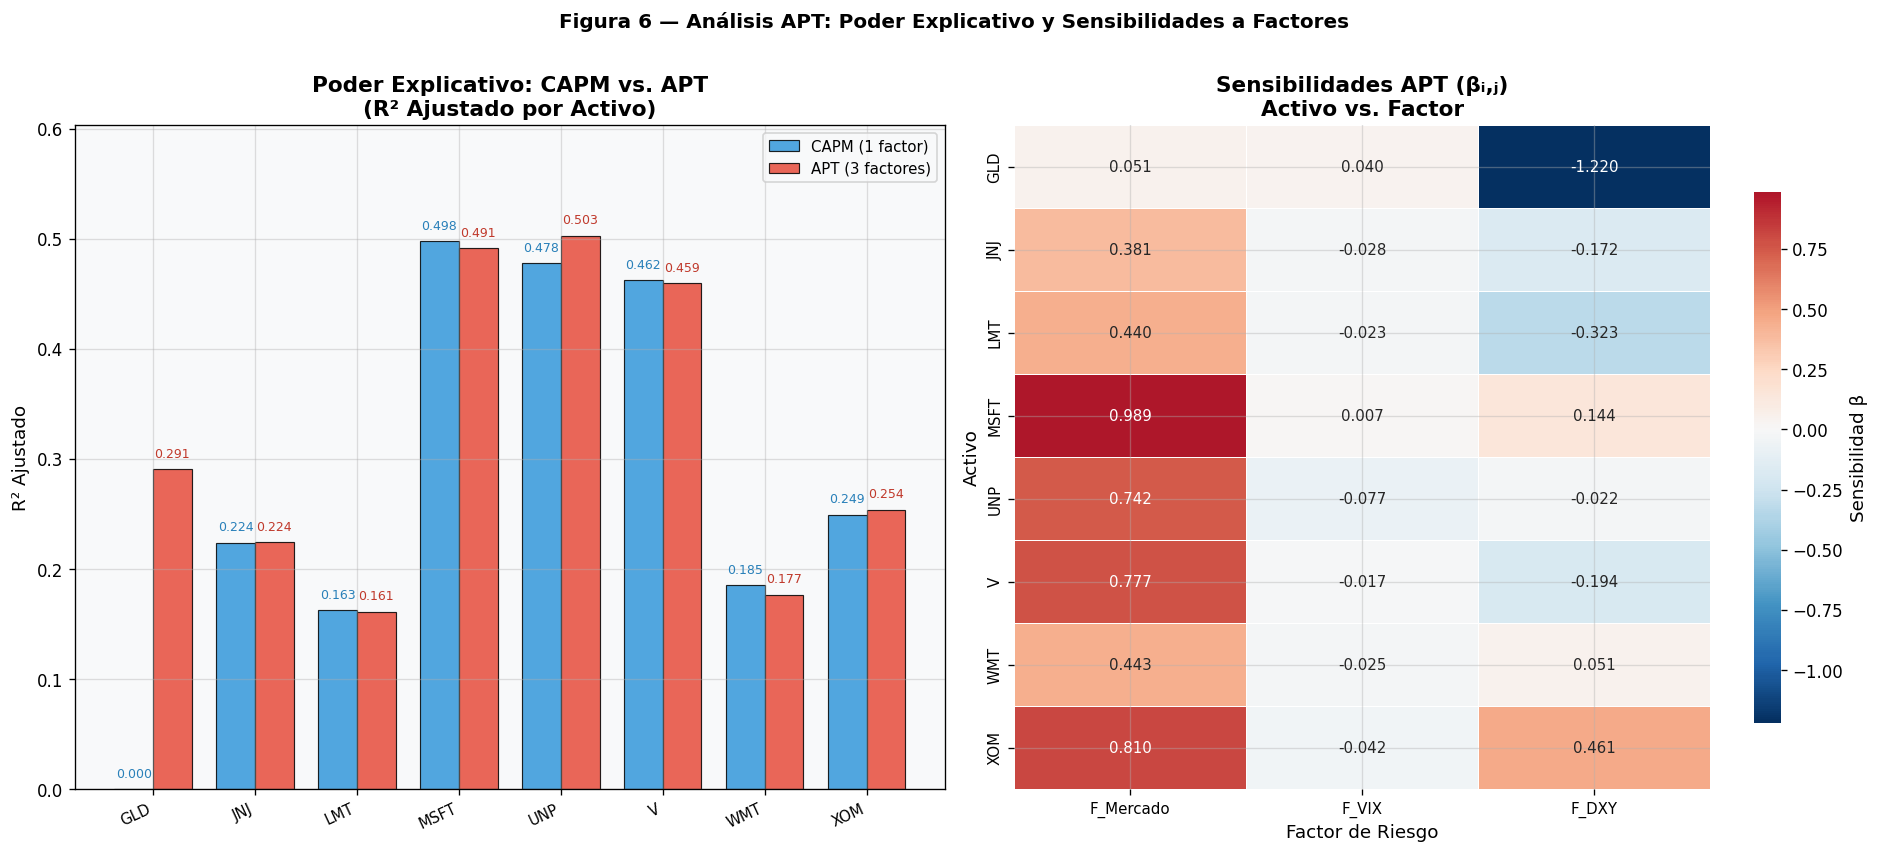

Figura 6 guardada.


In [19]:
# FASE 3: Visualizaciones del modelo APT
#

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ─── Gráfico izquierdo: Comparación de R² ajustado CAPM vs APT ───
x_act  = np.arange(N)
width  = 0.38
bars1  = axes[0].bar(x_act - width/2, comparacion_r2['R² aj. CAPM'], width,
                     label='CAPM (1 factor)',
                     color='#3498db', edgecolor='black', linewidth=0.7, alpha=0.85)
bars2  = axes[0].bar(x_act + width/2, comparacion_r2['R² aj. APT'], width,
                     label=f'APT ({len(FACTOR_NAMES)} factores)',
                     color='#e74c3c', edgecolor='black', linewidth=0.7, alpha=0.85)

for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.008,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=7.5, color='#2980b9')
for bar in bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.008,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=7.5, color='#c0392b')

axes[0].set_xticks(x_act)
axes[0].set_xticklabels(ACTIVOS, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('R² Ajustado')
axes[0].set_ylim(0, min(1.0, comparacion_r2[['R² aj. CAPM','R² aj. APT']].max().max() * 1.2))
axes[0].set_title('Poder Explicativo: CAPM vs. APT\n(R² Ajustado por Activo)',
                   fontweight='bold')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.5)

# ─── Gráfico derecho: Sensibilidades (Betas APT) por activo ───
# Mostramos las betas APT en un mapa de calor para interpretar qué factores
# son más relevantes para cada activo.
# betas_matrix ya fue construida en la celda anterior (Fama-MacBeth).
# La redefinimos aquí para que esta celda sea autocontenida si se ejecuta
# de forma aislada.
betas_matrix = pd.DataFrame(
    {activo: resultados_apt_dict[activo].params[FACTOR_NAMES] for activo in ACTIVOS}
).T
betas_matrix.columns = FACTOR_NAMES

sns.heatmap(betas_matrix, ax=axes[1], annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            cbar_kws={"label": "Sensibilidad β", "shrink": 0.8},
            annot_kws={"size": 9})
axes[1].set_title('Sensibilidades APT (βᵢ,ⱼ)\nActivo vs. Factor', fontweight='bold')
axes[1].set_xlabel('Factor de Riesgo')
axes[1].set_ylabel('Activo')
axes[1].tick_params(axis='both', labelsize=9)

plt.suptitle('Figura 6 — Análisis APT: Poder Explicativo y Sensibilidades a Factores',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig6_apt.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figura 6 guardada.")


---
## Fase 4 — Sensibilidad y Limitaciones

════════════════════════════════════════════════════════════════════
EXPERIMENTO A — SENSIBILIDAD A LA VENTANA TEMPORAL
════════════════════════════════════════════════════════════════════

  10 años (2016–2026)
    Sharpe=1.1850  |  Retorno=19.18%  |  Vol=12.53%
    Top-3 pesos: GLD=46.1%  |  WMT=24.6%  |  MSFT=23.3%

  7 años (2019–2026)
    Sharpe=1.2652  |  Retorno=20.90%  |  Vol=13.09%
    Top-3 pesos: GLD=51.2%  |  WMT=24.1%  |  MSFT=19.3%

  5 años (2021–2026)
    Sharpe=1.3560  |  Retorno=21.11%  |  Vol=12.37%
    Top-3 pesos: GLD=37.9%  |  XOM=24.6%  |  WMT=22.8%

  3 años (2023–2026)
    Sharpe=2.1429  |  Retorno=29.07%  |  Vol=11.54%
    Top-3 pesos: GLD=48.1%  |  WMT=28.6%  |  MSFT=15.0%

════════════════════════════════════════════════════════════════════
EXPERIMENTO B — SENSIBILIDAD A LA TASA LIBRE DE RIESGO
════════════════════════════════════════════════════════════════════
  Rf = 1.00%  →  SR = 1.4575  |  σ_tang = 11.92%  |  μ_tang = 18.38%
  Rf = 2.00%  →  SR = 1.3742

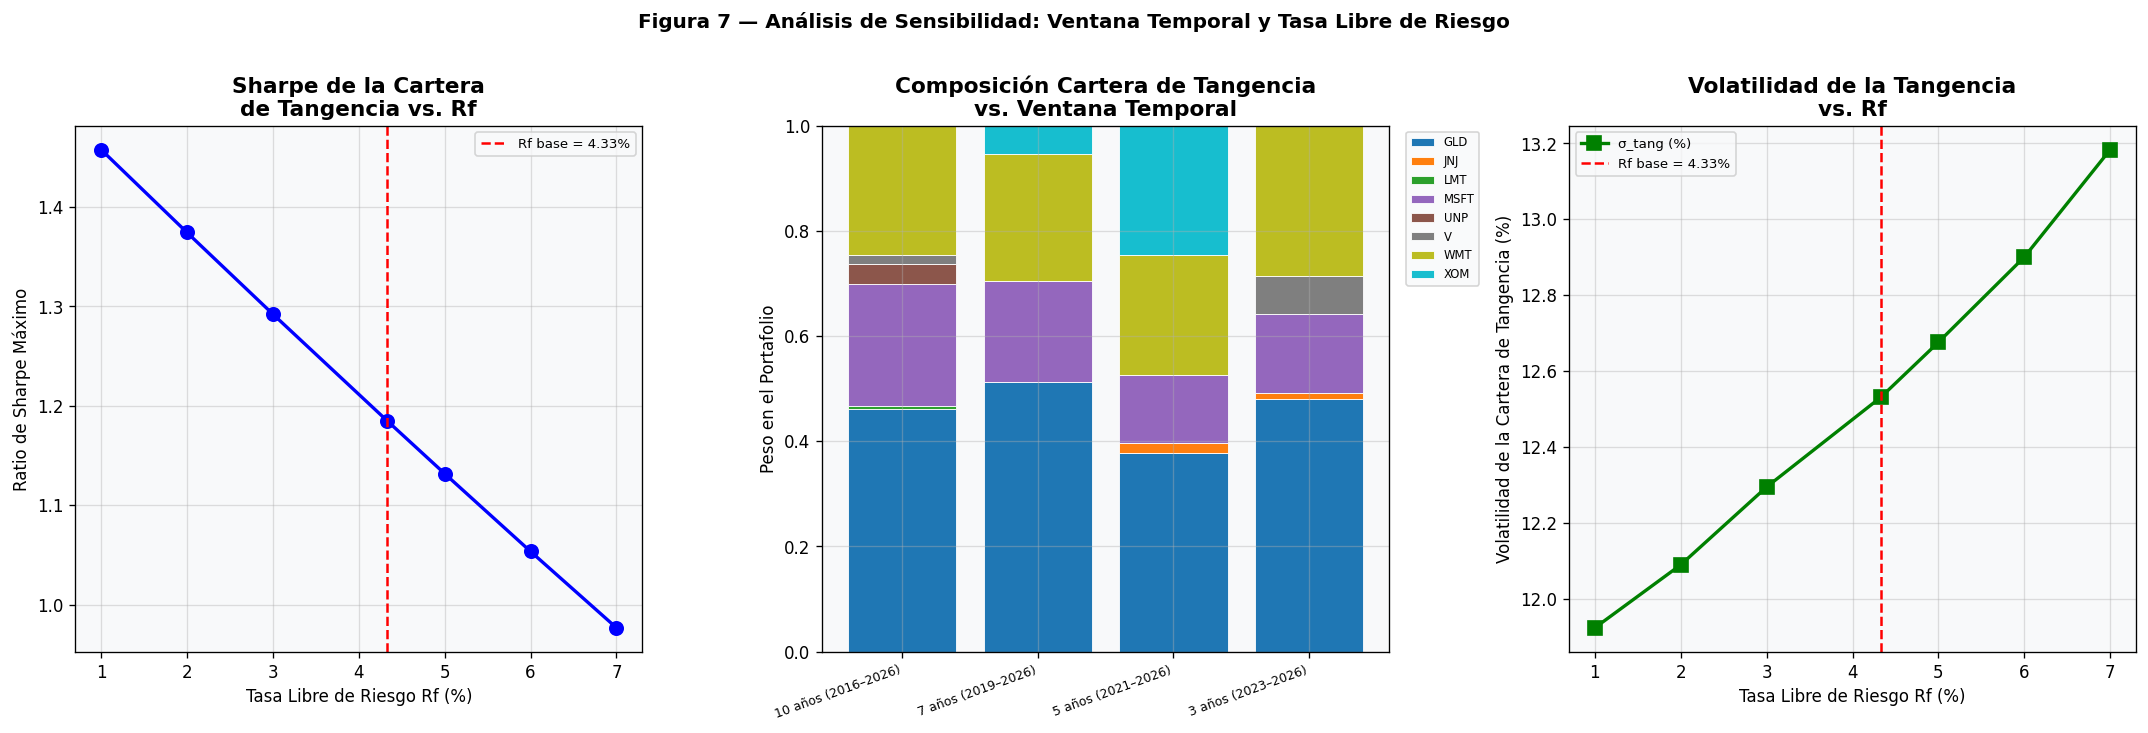


Figura 7 guardada.


In [20]:
# FASE 4: Análisis de Sensibilidad
# 
# En los modelos financieros teóricos, los resultados dependen críticamente de
# supuestos que en la práctica son inciertos. Esta fase examina la ROBUSTEZ de
# nuestros resultados al variar dos supuestos clave:
#
# EXPERIMENTO A — Ventana temporal:
#   ¿Cambia la Cartera de Tangencia si usamos 3, 5 o 10 años de historia?
#   Impacto esperado: ventanas cortas son más ruidosas pero más reactivas a
#   régimen actual; ventanas largas son más estables pero pueden incluir
#   regímenes económicos obsoletos.
#
# EXPERIMENTO B — Tasa libre de riesgo:
#   ¿Cómo cambia el Ratio de Sharpe de la cartera óptima si Rf varía entre 1% y 6%?
#   Impacto esperado: al aumentar Rf, el Sharpe decrece porque el numerador
#   (E[Rp] − Rf) se reduce mientras el denominador (σp) permanece constante.

print("═" * 68)
print("EXPERIMENTO A — SENSIBILIDAD A LA VENTANA TEMPORAL")
print("═" * 68)

ventanas = {
    '10 años (2016–2026)': ('2016-01-01', '2026-01-01'),
    '7 años (2019–2026)':  ('2019-01-01', '2026-01-01'),
    '5 años (2021–2026)':  ('2021-01-01', '2026-01-01'),
    '3 años (2023–2026)':  ('2023-01-01', '2026-01-01'),
}

resultados_ventanas = {}
for etiqueta, (t0, t1) in ventanas.items():
    mask = (ret_activos.index >= t0) & (ret_activos.index < t1)
    ra_v = ret_activos[mask]
    mu_v = ra_v.mean()  * TRADING_DAYS
    cv_v = ra_v.cov()   * TRADING_DAYS

    pw, srt = maximizar_sharpe_ratio(mu_v, cv_v, RF_ANUAL)
    rt, vt, _ = calcular_metricas_portafolio(pw, mu_v, cv_v)
    resultados_ventanas[etiqueta] = {'SR': srt, 'Ret': rt, 'Vol': vt, 'Pesos': pw}
    print(f"\n  {etiqueta}")
    print(f"    Sharpe={srt:.4f}  |  Retorno={rt:.2%}  |  Vol={vt:.2%}")
    top3 = sorted(zip(ACTIVOS, pw), key=lambda x: -x[1])[:3]
    print(f"    Top-3 pesos: " + "  |  ".join([f"{a}={w:.1%}" for a, w in top3 if w > 0.01]))

print("\n" + "═" * 68)
print("EXPERIMENTO B — SENSIBILIDAD A LA TASA LIBRE DE RIESGO")
print("═" * 68)
rf_vals   = [0.01, 0.02, 0.03, 0.0433, 0.05, 0.06, 0.07]
sr_vals   = []
vol_tang_vals = []
ret_tang_vals = []
for rf_t in rf_vals:
    pw_t, sr_t = maximizar_sharpe_ratio(mu_anual, cov_anual, rf_t)
    rt_t, vt_t, _ = calcular_metricas_portafolio(pw_t, mu_anual, cov_anual, rf_t)
    sr_vals.append(sr_t)
    vol_tang_vals.append(vt_t)
    ret_tang_vals.append(rt_t)
    print(f"  Rf = {rf_t:.2%}  →  SR = {sr_t:.4f}  |  σ_tang = {vt_t:.2%}  |  μ_tang = {rt_t:.2%}")

# ─── Figura 7 ───
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel A: Sharpe vs Rf
axes[0].plot([r*100 for r in rf_vals], sr_vals, 'bo-', markersize=8, linewidth=2)
axes[0].axvline(RF_ANUAL*100, color='red', linestyle='--', linewidth=1.5,
                label=f'Rf base = {RF_ANUAL:.2%}')
axes[0].set_xlabel('Tasa Libre de Riesgo Rf (%)', fontsize=10)
axes[0].set_ylabel('Ratio de Sharpe Máximo', fontsize=10)
axes[0].set_title('Sharpe de la Cartera\nde Tangencia vs. Rf', fontweight='bold')
axes[0].legend(fontsize=8)

# Panel B: Composición según ventana temporal
etqs = list(resultados_ventanas.keys())
pesos_m = np.array([[resultados_ventanas[e]['Pesos'][j] for j in range(N)] for e in etqs])
bot = np.zeros(len(etqs))
cmap_b = plt.cm.tab10(np.linspace(0, 1, N))
for j, activo in enumerate(ACTIVOS):
    axes[1].bar(etqs, pesos_m[:, j], bottom=bot, label=activo,
                color=cmap_b[j], edgecolor='white', linewidth=0.5)
    bot += pesos_m[:, j]
axes[1].set_ylabel('Peso en el Portafolio', fontsize=10)
axes[1].set_title('Composición Cartera de Tangencia\nvs. Ventana Temporal', fontweight='bold')
axes[1].set_xticklabels(etqs, rotation=20, ha='right', fontsize=7.5)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

# Panel C: Volatilidad de la cartera de tangencia vs Rf
axes[2].plot([r*100 for r in rf_vals], [v*100 for v in vol_tang_vals],
             'gs-', markersize=8, linewidth=2, label='σ_tang (%)')
axes[2].axvline(RF_ANUAL*100, color='red', linestyle='--', linewidth=1.5,
                label=f'Rf base = {RF_ANUAL:.2%}')
axes[2].set_xlabel('Tasa Libre de Riesgo Rf (%)', fontsize=10)
axes[2].set_ylabel('Volatilidad de la Cartera de Tangencia (%)', fontsize=10)
axes[2].set_title('Volatilidad de la Tangencia\nvs. Rf', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Figura 7 — Análisis de Sensibilidad: Ventana Temporal y Tasa Libre de Riesgo',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig7_sensibilidad.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nFigura 7 guardada.")


## Limitaciones Metodológicas

### 1. Supuesto de Normalidad
Los retornos exhiben **curtosis excesiva** y **asimetría negativa** (verificado en Celda 7). Esto implica que el CAPM y Markowitz subestiman el riesgo de eventos extremos (*tail risk*). Una extensión natural sería usar distribuciones *t*-Student o modelos GARCH.

### 2. Estacionariedad de la Covarianza
La Frontera Eficiente se calcula con la covarianza histórica del periodo completo (2016–2026), asumiendo que es estable. La Fase 4 demostró que esto NO se cumple: la composición óptima varía significativamente con la ventana temporal.

### 3. Correlaciones en Crisis
Durante periodos de estrés (COVID-19, 2022), las correlaciones entre activos tienden a **1**, eliminando el beneficio de la diversificación exactamente cuando más se necesita.

### 4. Factores APT
Los factores macroeconómicos seleccionados capturan riesgo sistemático pero no son exhaustivos. La literatura sugiere también incluir: **SMB** (size factor), **HML** (value factor) y **MOM** (momentum) del modelo de Fama-French.

### 5. Estimación del Beta
La β es altamente sensible a la frecuencia de los datos y a la ventana de estimación. Betas calculadas con datos diarios vs. mensuales pueden diferir notablemente.

### 6. Compatibilidad de librerías
`pandas_datareader` fue descartado por incompatibilidad con Python 3.12+. Los datos de FRED se obtienen directamente vía API REST con `requests`, lo cual es igualmente reproducible pero requiere conexión a internet en tiempo de ejecución.

### 7. Primas de Riesgo APT (λ) y Sesgo por Errors-in-Variables
Las λ estimadas por Fama-MacBeth utilizan las betas como regresores en corte transversal. Esta estimación asume que las betas son estables en el tiempo (hipótesis del modelo de factores). En la práctica, las betas varían con el régimen de mercado; una extensión robusta usaría betas rolling en la segunda etapa.

Adicionalmente, la estimación Fama-MacBeth asume que las β de la primera etapa son conocidas sin error. En la realidad, son estimaciones ruidosas; al usarlas como regresores deterministas en la segunda etapa se incurre en el sesgo clásico de *Errors-in-Variables* (EIV): los errores estándar de las primas de riesgo (λ) se subestiman, lo que infla artificialmente los estadísticos *t* y reduce los *p*-valores. Una corrección rigurosa requeriría el ajuste de **Shanken (1992)**, que escala los errores estándar por un factor que depende de la varianza de las betas estimadas.


---
## Conclusiones

In [22]:
# RESUMEN FINAL Y CONCLUSIONES
#
# Integramos los resultados de las cuatro fases en una tabla consolidada y
# respondemos la pregunta central del proyecto.

print("╔" + "═"*72 + "╗")
print("║" + "  RESUMEN EJECUTIVO DEL PROYECTO FINAL".center(72) + "║")
print("║" + "  Métodos Cuantitativos en Finanzas — UNAM Semestre 2026-2".center(72) + "║")
print("╠" + "═"*72 + "╣")
print("║" + "  FASE 1 — MARKOWITZ".ljust(72) + "║")
print(f"║  • MVP:   σ={mvp['Volatilidad']:.2%}, μ={mvp['Retorno']:.2%}, SR={mvp['Sharpe']:.3f}".ljust(73)+"║")
print(f"║  • GLD es el activo individual de menor volatilidad en el portafolio.".ljust(73)+"║")
print("╠" + "═"*72 + "╣")
print("║" + "  FASE 2 — CAPM".ljust(72) + "║")
print(f"║  • Cartera Tangencia: σ={vol_tang:.2%}, μ={ret_tang:.2%}, SR={sr_tang:.3f}".ljust(73)+"║")
print(f"║  • La CAL domina la Frontera Eficiente (riesgo-rendimiento superior).".ljust(73)+"║")
beta_prom = df_capm['Beta'].mean()
print(f"║  • Beta promedio del portafolio: {beta_prom:.3f}".ljust(73)+"║")
print("╠" + "═"*72 + "╣")
print("║" + "  FASE 3 — APT".ljust(72) + "║")
r2_prom_capm = comparacion_r2['R² aj. CAPM'].mean()
r2_prom_apt  = comparacion_r2['R² aj. APT'].mean()
n_mej = (comparacion_r2['Δ R²'] > 0).sum()
print(f"║  • Factores: {', '.join(FACTOR_NAMES)}".ljust(73)+"║")
print(f"║  • R² adj promedio CAPM: {r2_prom_capm:.4f}  |  R² adj promedio APT: {r2_prom_apt:.4f}".ljust(73)+"║")
if r2_prom_apt > r2_prom_capm:
    concl = f"APT SUPERA al CAPM en {n_mej}/{N} activos (Δ R² = {r2_prom_apt-r2_prom_capm:+.4f})"
else:
    concl = f"CAPM comparable al APT (Δ R² = {r2_prom_apt-r2_prom_capm:+.4f})"
print(f"║  • Conclusión: {concl}".ljust(73)+"║")
print("╠" + "═"*72 + "╣")
print("║" + "  FASE 4 — SENSIBILIDAD Y LIMITACIONES".ljust(72) + "║")
print("║  • La composición de la cartera óptima varía significativamente con".ljust(73)+"║")
print("║    la ventana temporal: el modelo es sensible al régimen de mercado.".ljust(73)+"║")
print("║  • El Sharpe decrece monotónamente al aumentar Rf, como es esperado.".ljust(73)+"║")
print("║  • Limitaciones: no-normalidad de retornos, estacionariedad dudosa,".ljust(73)+"║")
print("║    correlaciones no constantes y omisión del riesgo de liquidez.".ljust(73)+"║")
print("╚" + "═"*72 + "╝")

# ─── Tabla final consolidada ───
print("\n\nTABLA FINAL CONSOLIDADA — MÉTRICAS CAPM y APT POR ACTIVO")
print("=" * 80)
tabla_final = pd.DataFrame({
    'β CAPM':       df_capm['Beta'].round(3),
    'α Jensen (%)': (df_capm['Alpha_Anual']*100).round(2),
    'R²adj CAPM(d)': pd.Series(r2_adj_capm_daily).round(4),  # R² ajustado diario (Fase 2)
    'R² APT':       comparacion_r2['R² aj. APT'].round(4),
    'Δ R²':         comparacion_r2['Δ R²'].round(4),
    'μ_hist (%)':   (df_capm['Retorno_Hist']*100).round(2),
    'μ_CAPM (%)':   (df_capm['Retorno_CAPM']*100).round(2),
})
print(tabla_final.to_string())
print("\n* Nota: 'R²adj CAPM(d)' = R² ajustado CAPM con datos diarios (Fase 2).")
print("* 'R² APT' = R² ajustado APT con datos mensuales (Fase 3). Son comparables")
print("*            en términos de poder explicativo de sus respectivos modelos.")


╔════════════════════════════════════════════════════════════════════════╗
║                   RESUMEN EJECUTIVO DEL PROYECTO FINAL                 ║
║         Métodos Cuantitativos en Finanzas — UNAM Semestre 2026-2       ║
╠════════════════════════════════════════════════════════════════════════╣
║  FASE 1 — MARKOWITZ                                                    ║
║  • MVP:   σ=10.78%, μ=15.20%, SR=1.008                                 ║
║  • GLD es el activo individual de menor volatilidad en el portafolio.  ║
╠════════════════════════════════════════════════════════════════════════╣
║  FASE 2 — CAPM                                                         ║
║  • Cartera Tangencia: σ=12.53%, μ=19.18%, SR=1.185                     ║
║  • La CAL domina la Frontera Eficiente (riesgo-rendimiento superior).  ║
║  • Beta promedio del portafolio: 0.686                                 ║
╠════════════════════════════════════════════════════════════════════════╣
║  FASE 3 — APT          